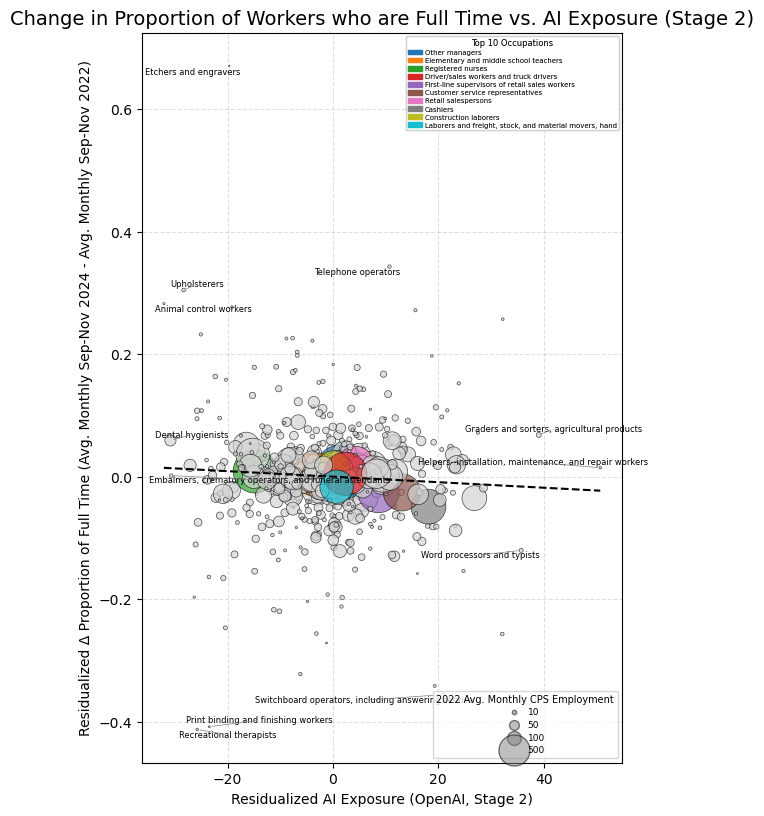

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
import matplotlib.patches as mpatches
import pandas as pd
import textwrap
import statsmodels.api as sm
import numpy as np

# Load data
df = pd.read_stata("Data/Cleaned/6M_residuals_for_plots.dta")

# Clean and prep
plot_df = df[['cps_code', 'cps_title', 'openai2_resid', 'd_fulltime_resid', 'avg_monthly_emp']].dropna()
plot_df['cps_code'] = plot_df['cps_code'].astype(str)

# Top 10 occupations
top_cps_codes = ['440', '2310', '3255', '9130', '4700', '5240', '4760', '4720', '6260', '9620']
palette = sns.color_palette("tab10", len(top_cps_codes))
color_map = dict(zip(top_cps_codes, palette))

# Assign colors
plot_df['color'] = plot_df['cps_code'].apply(lambda x: color_map[x] if x in top_cps_codes else 'lightgray')

# Define edge outliers using axis extremes
edge_df = pd.concat([
    plot_df.nsmallest(3, 'openai2_resid'),
    plot_df.nlargest(3, 'openai2_resid'),
    plot_df.nsmallest(3, 'd_fulltime_resid'),
    plot_df.nlargest(3, 'd_fulltime_resid')
]).drop_duplicates()

# Label only those outliers
plot_df['edge_label'] = plot_df.apply(
    lambda row: row['cps_title'] if row['cps_title'] in edge_df['cps_title'].values else None,
    axis=1
)

# Create plot
fig, ax = plt.subplots(figsize=(8, 10))

# Bubble scatter
ax.scatter(
    plot_df['openai2_resid'],
    plot_df['d_fulltime_resid'],
    s=plot_df['avg_monthly_emp'],
    color=plot_df['color'],
    alpha=0.7,
    edgecolors='black',
    linewidths=0.5
)

# Drop NA rows used for regression
dfw = plot_df.dropna(subset=['openai2_resid', 'd_fulltime_resid', 'avg_monthly_emp'])

# Define X, y, and weights
X = sm.add_constant(dfw['openai2_resid'])
y = dfw['d_fulltime_resid']
weights = dfw['avg_monthly_emp']

# Fit weighted least squares model
wls_model = sm.WLS(y, X, weights=weights)
results = wls_model.fit()

# Predict values for plotting the regression line
x_vals = np.linspace(dfw['openai2_resid'].min(), dfw['openai2_resid'].max(), 100)
X_pred = sm.add_constant(x_vals)
y_pred = results.predict(X_pred)

# Plot weighted regression line
ax.plot(x_vals, y_pred, color='black', linestyle='--', linewidth=1.5, label='Weighted Regression')
ax.legend()

# --- Bubble Size Legend (top right) ---
bubble_legend = [
    plt.scatter([], [], s=size, c='gray', alpha=0.5, edgecolors='k', label=f'{size:,}')
    for size in [10, 50, 100, 500]
]

bubble_legend_obj = ax.legend(
    handles=bubble_legend,
    title='2022 Avg. Monthly CPS Employment',
    loc='lower right',
    fontsize=6.5,
    title_fontsize=7,
    frameon=True,
    labelspacing=0.4,
    handletextpad=0.5,
    borderpad=0.4
)

# --- Occupation Color Legend (bottom right) ---
patches = [
    mpatches.Patch(color=color_map[code], label=plot_df[plot_df['cps_code'] == code]['cps_title'].iloc[0])
    for code in top_cps_codes
]

occupation_legend_obj = ax.legend(
    handles=patches,
    title='Top 10 Occupations',
    loc='upper right',
    fontsize=5,
    title_fontsize=6,
    frameon=True,
    labelspacing=0.3,
    handletextpad=0.4,
    borderpad=0.3,
    ncol=1
)

# Add both legends to plot
ax.add_artist(bubble_legend_obj)
ax.add_artist(occupation_legend_obj)



from adjustText import adjust_text

texts = []

# Create label texts directly *at the point* — let adjustText do all movement
for _, row in plot_df[plot_df['edge_label'].notnull()].iterrows():
    texts.append(
        ax.text(
            row['openai2_resid'],
            row['d_fulltime_resid'],
            row['edge_label'],
            fontsize=6,
            ha='center',
            va='center'
        )
    )

# Adjust placement with proper arrows
adjust_text(
    texts,
    x=plot_df.loc[plot_df['edge_label'].notnull(), 'openai2_resid'],
    y=plot_df.loc[plot_df['edge_label'].notnull(), 'd_fulltime_resid'],
    arrowprops=dict(
        arrowstyle='-', 
        color='gray', 
        lw=0.5,
        shrinkA=2,  # shrink arrowhead from text
        shrinkB=2   # shrink arrowhead from point
    ),
    expand_text=(1.2, 1.4),
    expand_points=(1.2, 1.4),
    ax=ax
)


# Final polish
ax.set_title("Change in Proportion of Workers who are Full Time vs. AI Exposure (Stage 2)", fontsize=14)
ax.set_xlabel("Residualized AI Exposure (OpenAI, Stage 2)")
ax.set_ylabel("Residualized Δ Proportion of Full Time (Avg. Monthly Sep-Nov 2024 - Avg. Monthly Sep-Nov 2022)")
ax.grid(True, linestyle='--', alpha=0.4)

fig.tight_layout()
fig.subplots_adjust(right=0.75, left=0.15, top=0.88, bottom=0.15)

# Save
plt.savefig("Output/April/Bubble3/Base_FT_6MS2_OA.png", dpi=300, bbox_inches='tight')
plt.show()


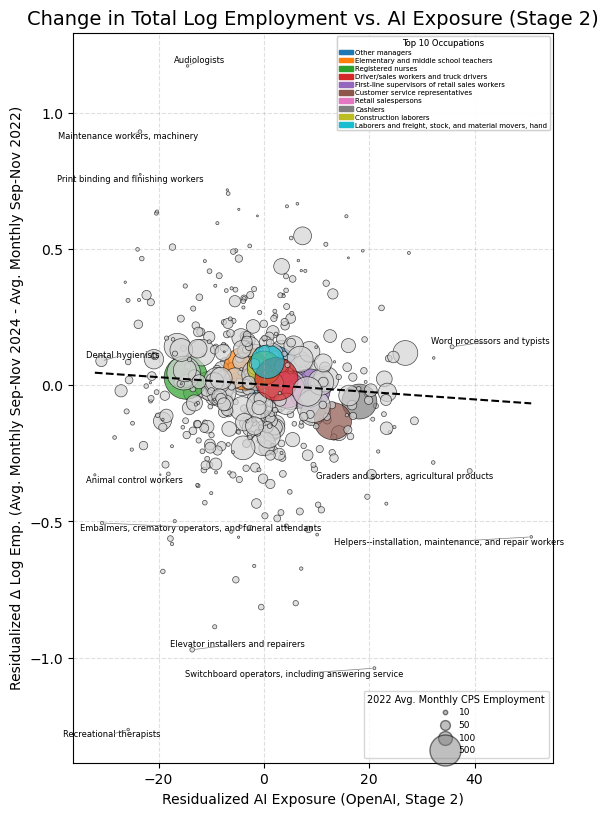

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
import matplotlib.patches as mpatches
import pandas as pd
import textwrap
import statsmodels.api as sm
import numpy as np

# Load data
df = pd.read_stata("Data/Cleaned/6M_residuals_for_plots.dta")

# Clean and prep
plot_df = df[['cps_code', 'cps_title', 'openai2_resid', 'd_log_emp_resid', 'avg_monthly_emp']].dropna()
plot_df['cps_code'] = plot_df['cps_code'].astype(str)

# Top 10 occupations
top_cps_codes = ['440', '2310', '3255', '9130', '4700', '5240', '4760', '4720', '6260', '9620']
palette = sns.color_palette("tab10", len(top_cps_codes))
color_map = dict(zip(top_cps_codes, palette))

# Assign colors
plot_df['color'] = plot_df['cps_code'].apply(lambda x: color_map[x] if x in top_cps_codes else 'lightgray')

# Define edge outliers using axis extremes
edge_df = pd.concat([
    plot_df.nsmallest(3, 'openai2_resid'),
    plot_df.nlargest(3, 'openai2_resid'),
    plot_df.nsmallest(3, 'd_log_emp_resid'),
    plot_df.nlargest(3, 'd_log_emp_resid')
]).drop_duplicates()

# Label only those outliers
plot_df['edge_label'] = plot_df.apply(
    lambda row: row['cps_title'] if row['cps_title'] in edge_df['cps_title'].values else None,
    axis=1
)

# Create plot
fig, ax = plt.subplots(figsize=(8, 10))

# Bubble scatter
ax.scatter(
    plot_df['openai2_resid'],
    plot_df['d_log_emp_resid'],
    s=plot_df['avg_monthly_emp'],
    color=plot_df['color'],
    alpha=0.7,
    edgecolors='black',
    linewidths=0.5
)

# Drop NA rows used for regression
dfw = plot_df.dropna(subset=['openai2_resid', 'd_log_emp_resid', 'avg_monthly_emp'])

# Define X, y, and weights
X = sm.add_constant(dfw['openai2_resid'])
y = dfw['d_log_emp_resid']
weights = dfw['avg_monthly_emp']

# Fit weighted least squares model
wls_model = sm.WLS(y, X, weights=weights)
results = wls_model.fit()

# Predict values for plotting the regression line
x_vals = np.linspace(dfw['openai2_resid'].min(), dfw['openai2_resid'].max(), 100)
X_pred = sm.add_constant(x_vals)
y_pred = results.predict(X_pred)

# Plot weighted regression line
ax.plot(x_vals, y_pred, color='black', linestyle='--', linewidth=1.5, label='Weighted Regression')
ax.legend()

# --- Bubble Size Legend (top right) ---
bubble_legend = [
    plt.scatter([], [], s=size, c='gray', alpha=0.5, edgecolors='k', label=f'{size:,}')
    for size in [10, 50, 100, 500]
]

bubble_legend_obj = ax.legend(
    handles=bubble_legend,
    title='2022 Avg. Monthly CPS Employment',
    loc='lower right',
    fontsize=6.5,
    title_fontsize=7,
    frameon=True,
    labelspacing=0.4,
    handletextpad=0.5,
    borderpad=0.4
)

# --- Occupation Color Legend (bottom right) ---
patches = [
    mpatches.Patch(color=color_map[code], label=plot_df[plot_df['cps_code'] == code]['cps_title'].iloc[0])
    for code in top_cps_codes
]

occupation_legend_obj = ax.legend(
    handles=patches,
    title='Top 10 Occupations',
    loc='upper right',
    fontsize=5,
    title_fontsize=6,
    frameon=True,
    labelspacing=0.3,
    handletextpad=0.4,
    borderpad=0.3,
    ncol=1
)

# Add both legends to plot
ax.add_artist(bubble_legend_obj)
ax.add_artist(occupation_legend_obj)



from adjustText import adjust_text

texts = []

# Create label texts directly *at the point* — let adjustText do all movement
for _, row in plot_df[plot_df['edge_label'].notnull()].iterrows():
    texts.append(
        ax.text(
            row['openai2_resid'],
            row['d_log_emp_resid'],
            row['edge_label'],
            fontsize=6,
            ha='center',
            va='center'
        )
    )

# Adjust placement with proper arrows
adjust_text(
    texts,
    x=plot_df.loc[plot_df['edge_label'].notnull(), 'openai2_resid'],
    y=plot_df.loc[plot_df['edge_label'].notnull(), 'd_log_emp_resid'],
    arrowprops=dict(
        arrowstyle='-', 
        color='gray', 
        lw=0.5,
        shrinkA=2,  # shrink arrowhead from text
        shrinkB=2   # shrink arrowhead from point
    ),
    expand_text=(1.2, 1.4),
    expand_points=(1.2, 1.4),
    ax=ax
)


# Final polish
ax.set_title("Change in Total Log Employment vs. AI Exposure (Stage 2)", fontsize=14)
ax.set_xlabel("Residualized AI Exposure (OpenAI, Stage 2)")
ax.set_ylabel("Residualized Δ Log Emp. (Avg. Monthly Sep-Nov 2024 - Avg. Monthly Sep-Nov 2022)")
ax.grid(True, linestyle='--', alpha=0.4)

fig.tight_layout()
fig.subplots_adjust(right=0.75, left=0.15, top=0.88, bottom=0.15)

# Save
plt.savefig("Output/April/Bubble3/Base_EMP_6MS2_OA.png", dpi=300, bbox_inches='tight')
plt.show()


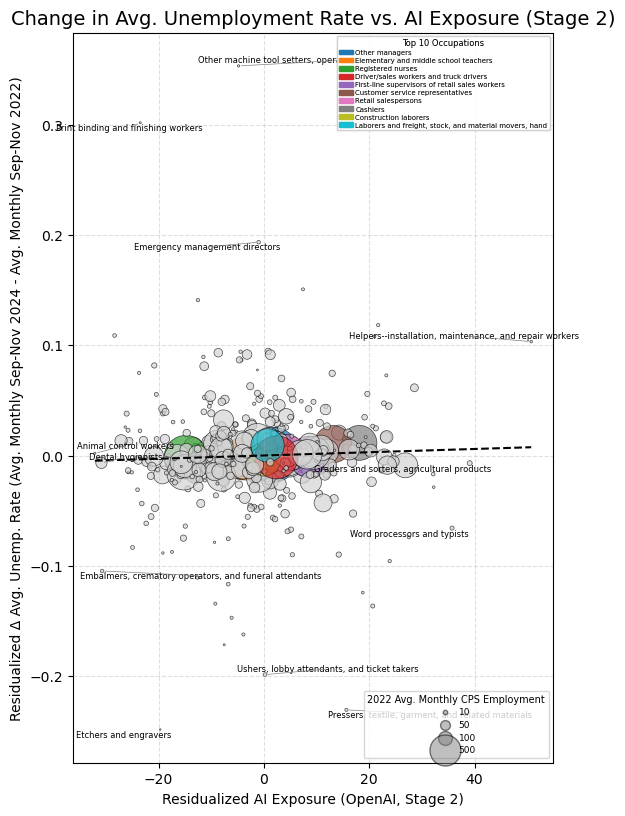

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
import matplotlib.patches as mpatches
import pandas as pd
import textwrap
import statsmodels.api as sm
import numpy as np

# Load data
df = pd.read_stata("Data/Cleaned/6M_residuals_for_plots.dta")

# Clean and prep
plot_df = df[['cps_code', 'cps_title', 'openai2_resid', 'd_unemp_rate_resid', 'avg_monthly_emp']].dropna()
plot_df['cps_code'] = plot_df['cps_code'].astype(str)

# Top 10 occupations
top_cps_codes = ['440', '2310', '3255', '9130', '4700', '5240', '4760', '4720', '6260', '9620']
palette = sns.color_palette("tab10", len(top_cps_codes))
color_map = dict(zip(top_cps_codes, palette))

# Assign colors
plot_df['color'] = plot_df['cps_code'].apply(lambda x: color_map[x] if x in top_cps_codes else 'lightgray')

# Define edge outliers using axis extremes
edge_df = pd.concat([
    plot_df.nsmallest(3, 'openai2_resid'),
    plot_df.nlargest(3, 'openai2_resid'),
    plot_df.nsmallest(3, 'd_unemp_rate_resid'),
    plot_df.nlargest(3, 'd_unemp_rate_resid')
]).drop_duplicates()

# Label only those outliers
plot_df['edge_label'] = plot_df.apply(
    lambda row: row['cps_title'] if row['cps_title'] in edge_df['cps_title'].values else None,
    axis=1
)

# Create plot
fig, ax = plt.subplots(figsize=(8, 10))

# Bubble scatter
ax.scatter(
    plot_df['openai2_resid'],
    plot_df['d_unemp_rate_resid'],
    s=plot_df['avg_monthly_emp'],
    color=plot_df['color'],
    alpha=0.7,
    edgecolors='black',
    linewidths=0.5
)

# Drop NA rows used for regression
dfw = plot_df.dropna(subset=['openai2_resid', 'd_unemp_rate_resid', 'avg_monthly_emp'])

# Define X, y, and weights
X = sm.add_constant(dfw['openai2_resid'])
y = dfw['d_unemp_rate_resid']
weights = dfw['avg_monthly_emp']

# Fit weighted least squares model
wls_model = sm.WLS(y, X, weights=weights)
results = wls_model.fit()

# Predict values for plotting the regression line
x_vals = np.linspace(dfw['openai2_resid'].min(), dfw['openai2_resid'].max(), 100)
X_pred = sm.add_constant(x_vals)
y_pred = results.predict(X_pred)

# Plot weighted regression line
ax.plot(x_vals, y_pred, color='black', linestyle='--', linewidth=1.5, label='Weighted Regression')
ax.legend()

# --- Bubble Size Legend (top right) ---
bubble_legend = [
    plt.scatter([], [], s=size, c='gray', alpha=0.5, edgecolors='k', label=f'{size:,}')
    for size in [10, 50, 100, 500]
]

bubble_legend_obj = ax.legend(
    handles=bubble_legend,
    title='2022 Avg. Monthly CPS Employment',
    loc='lower right',
    fontsize=6.5,
    title_fontsize=7,
    frameon=True,
    labelspacing=0.4,
    handletextpad=0.5,
    borderpad=0.4
)

# --- Occupation Color Legend (bottom right) ---
patches = [
    mpatches.Patch(color=color_map[code], label=plot_df[plot_df['cps_code'] == code]['cps_title'].iloc[0])
    for code in top_cps_codes
]

occupation_legend_obj = ax.legend(
    handles=patches,
    title='Top 10 Occupations',
    loc='upper right',
    fontsize=5,
    title_fontsize=6,
    frameon=True,
    labelspacing=0.3,
    handletextpad=0.4,
    borderpad=0.3,
    ncol=1
)

# Add both legends to plot
ax.add_artist(bubble_legend_obj)
ax.add_artist(occupation_legend_obj)



from adjustText import adjust_text

texts = []

# Create label texts directly *at the point* — let adjustText do all movement
for _, row in plot_df[plot_df['edge_label'].notnull()].iterrows():
    texts.append(
        ax.text(
            row['openai2_resid'],
            row['d_unemp_rate_resid'],
            row['edge_label'],
            fontsize=6,
            ha='center',
            va='center'
        )
    )

# Adjust placement with proper arrows
adjust_text(
    texts,
    x=plot_df.loc[plot_df['edge_label'].notnull(), 'openai2_resid'],
    y=plot_df.loc[plot_df['edge_label'].notnull(), 'd_unemp_rate_resid'],
    arrowprops=dict(
        arrowstyle='-', 
        color='gray', 
        lw=0.5,
        shrinkA=2,  # shrink arrowhead from text
        shrinkB=2   # shrink arrowhead from point
    ),
    expand_text=(1.2, 1.4),
    expand_points=(1.2, 1.4),
    ax=ax
)


# Final polish
ax.set_title("Change in Avg. Unemployment Rate vs. AI Exposure (Stage 2)", fontsize=14)
ax.set_xlabel("Residualized AI Exposure (OpenAI, Stage 2)")
ax.set_ylabel("Residualized Δ Avg. Unemp. Rate (Avg. Monthly Sep-Nov 2024 - Avg. Monthly Sep-Nov 2022)")
ax.grid(True, linestyle='--', alpha=0.4)

fig.tight_layout()
fig.subplots_adjust(right=0.75, left=0.15, top=0.88, bottom=0.15)

# Save
plt.savefig("Output/April/Bubble3/Base_UNEMP_6MS2_OA.png", dpi=300, bbox_inches='tight')
plt.show()


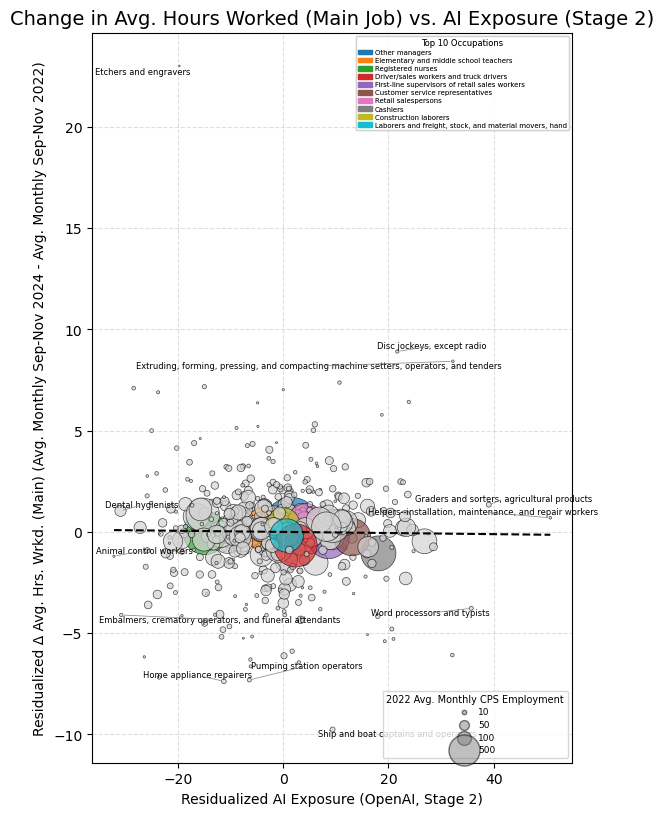

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
import matplotlib.patches as mpatches
import pandas as pd
import textwrap
import statsmodels.api as sm
import numpy as np

# Load data
df = pd.read_stata("Data/Cleaned/6M_residuals_for_plots.dta")

# Clean and prep
plot_df = df[['cps_code', 'cps_title', 'openai2_resid', 'd_ahrswork1_resid', 'avg_monthly_emp']].dropna()
plot_df['cps_code'] = plot_df['cps_code'].astype(str)

# Top 10 occupations
top_cps_codes = ['440', '2310', '3255', '9130', '4700', '5240', '4760', '4720', '6260', '9620']
palette = sns.color_palette("tab10", len(top_cps_codes))
color_map = dict(zip(top_cps_codes, palette))

# Assign colors
plot_df['color'] = plot_df['cps_code'].apply(lambda x: color_map[x] if x in top_cps_codes else 'lightgray')

# Define edge outliers using axis extremes
edge_df = pd.concat([
    plot_df.nsmallest(3, 'openai2_resid'),
    plot_df.nlargest(3, 'openai2_resid'),
    plot_df.nsmallest(3, 'd_ahrswork1_resid'),
    plot_df.nlargest(3, 'd_ahrswork1_resid')
]).drop_duplicates()

# Label only those outliers
plot_df['edge_label'] = plot_df.apply(
    lambda row: row['cps_title'] if row['cps_title'] in edge_df['cps_title'].values else None,
    axis=1
)

# Create plot
fig, ax = plt.subplots(figsize=(8, 10))

# Bubble scatter
ax.scatter(
    plot_df['openai2_resid'],
    plot_df['d_ahrswork1_resid'],
    s=plot_df['avg_monthly_emp'],
    color=plot_df['color'],
    alpha=0.7,
    edgecolors='black',
    linewidths=0.5
)

# Drop NA rows used for regression
dfw = plot_df.dropna(subset=['openai2_resid', 'd_ahrswork1_resid', 'avg_monthly_emp'])

# Define X, y, and weights
X = sm.add_constant(dfw['openai2_resid'])
y = dfw['d_ahrswork1_resid']
weights = dfw['avg_monthly_emp']

# Fit weighted least squares model
wls_model = sm.WLS(y, X, weights=weights)
results = wls_model.fit()

# Predict values for plotting the regression line
x_vals = np.linspace(dfw['openai2_resid'].min(), dfw['openai2_resid'].max(), 100)
X_pred = sm.add_constant(x_vals)
y_pred = results.predict(X_pred)

# Plot weighted regression line
ax.plot(x_vals, y_pred, color='black', linestyle='--', linewidth=1.5, label='Weighted Regression')
ax.legend()

# --- Bubble Size Legend (top right) ---
bubble_legend = [
    plt.scatter([], [], s=size, c='gray', alpha=0.5, edgecolors='k', label=f'{size:,}')
    for size in [10, 50, 100, 500]
]

bubble_legend_obj = ax.legend(
    handles=bubble_legend,
    title='2022 Avg. Monthly CPS Employment',
    loc='lower right',
    fontsize=6.5,
    title_fontsize=7,
    frameon=True,
    labelspacing=0.4,
    handletextpad=0.5,
    borderpad=0.4
)

# --- Occupation Color Legend (bottom right) ---
patches = [
    mpatches.Patch(color=color_map[code], label=plot_df[plot_df['cps_code'] == code]['cps_title'].iloc[0])
    for code in top_cps_codes
]

occupation_legend_obj = ax.legend(
    handles=patches,
    title='Top 10 Occupations',
    loc='upper right',
    fontsize=5,
    title_fontsize=6,
    frameon=True,
    labelspacing=0.3,
    handletextpad=0.4,
    borderpad=0.3,
    ncol=1
)

# Add both legends to plot
ax.add_artist(bubble_legend_obj)
ax.add_artist(occupation_legend_obj)



from adjustText import adjust_text

texts = []

# Create label texts directly *at the point* — let adjustText do all movement
for _, row in plot_df[plot_df['edge_label'].notnull()].iterrows():
    texts.append(
        ax.text(
            row['openai2_resid'],
            row['d_ahrswork1_resid'],
            row['edge_label'],
            fontsize=6,
            ha='center',
            va='center'
        )
    )

# Adjust placement with proper arrows
adjust_text(
    texts,
    x=plot_df.loc[plot_df['edge_label'].notnull(), 'openai2_resid'],
    y=plot_df.loc[plot_df['edge_label'].notnull(), 'd_ahrswork1_resid'],
    arrowprops=dict(
        arrowstyle='-', 
        color='gray', 
        lw=0.5,
        shrinkA=2,  # shrink arrowhead from text
        shrinkB=2   # shrink arrowhead from point
    ),
    expand_text=(1.2, 1.4),
    expand_points=(1.2, 1.4),
    ax=ax
)


# Final polish
ax.set_title("Change in Avg. Hours Worked (Main Job) vs. AI Exposure (Stage 2)", fontsize=14)
ax.set_xlabel("Residualized AI Exposure (OpenAI, Stage 2)")
ax.set_ylabel("Residualized Δ Avg. Hrs. Wrkd. (Main) (Avg. Monthly Sep-Nov 2024 - Avg. Monthly Sep-Nov 2022)")
ax.grid(True, linestyle='--', alpha=0.4)

fig.tight_layout()
fig.subplots_adjust(right=0.75, left=0.15, top=0.88, bottom=0.15)

# Save
plt.savefig("Output/April/Bubble3/Base_AH1_6MS2_OA.png", dpi=300, bbox_inches='tight')
plt.show()


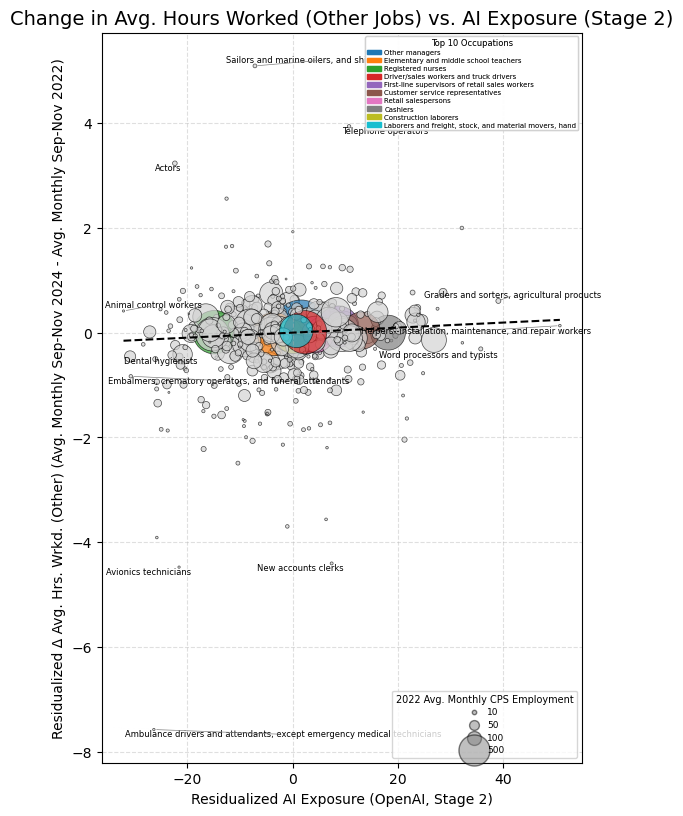

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
import matplotlib.patches as mpatches
import pandas as pd
import textwrap
import statsmodels.api as sm
import numpy as np

# Load data
df = pd.read_stata("Data/Cleaned/6M_residuals_for_plots.dta")

# Clean and prep
plot_df = df[['cps_code', 'cps_title', 'openai2_resid', 'd_ahrswork2_resid', 'avg_monthly_emp']].dropna()
plot_df['cps_code'] = plot_df['cps_code'].astype(str)

# Top 10 occupations
top_cps_codes = ['440', '2310', '3255', '9130', '4700', '5240', '4760', '4720', '6260', '9620']
palette = sns.color_palette("tab10", len(top_cps_codes))
color_map = dict(zip(top_cps_codes, palette))

# Assign colors
plot_df['color'] = plot_df['cps_code'].apply(lambda x: color_map[x] if x in top_cps_codes else 'lightgray')

# Define edge outliers using axis extremes
edge_df = pd.concat([
    plot_df.nsmallest(3, 'openai2_resid'),
    plot_df.nlargest(3, 'openai2_resid'),
    plot_df.nsmallest(3, 'd_ahrswork2_resid'),
    plot_df.nlargest(3, 'd_ahrswork2_resid')
]).drop_duplicates()

# Label only those outliers
plot_df['edge_label'] = plot_df.apply(
    lambda row: row['cps_title'] if row['cps_title'] in edge_df['cps_title'].values else None,
    axis=1
)

# Create plot
fig, ax = plt.subplots(figsize=(8, 10))

# Bubble scatter
ax.scatter(
    plot_df['openai2_resid'],
    plot_df['d_ahrswork2_resid'],
    s=plot_df['avg_monthly_emp'],
    color=plot_df['color'],
    alpha=0.7,
    edgecolors='black',
    linewidths=0.5
)

# Drop NA rows used for regression
dfw = plot_df.dropna(subset=['openai2_resid', 'd_ahrswork2_resid', 'avg_monthly_emp'])

# Define X, y, and weights
X = sm.add_constant(dfw['openai2_resid'])
y = dfw['d_ahrswork2_resid']
weights = dfw['avg_monthly_emp']

# Fit weighted least squares model
wls_model = sm.WLS(y, X, weights=weights)
results = wls_model.fit()

# Predict values for plotting the regression line
x_vals = np.linspace(dfw['openai2_resid'].min(), dfw['openai2_resid'].max(), 100)
X_pred = sm.add_constant(x_vals)
y_pred = results.predict(X_pred)

# Plot weighted regression line
ax.plot(x_vals, y_pred, color='black', linestyle='--', linewidth=1.5, label='Weighted Regression')
ax.legend()

# --- Bubble Size Legend (top right) ---
bubble_legend = [
    plt.scatter([], [], s=size, c='gray', alpha=0.5, edgecolors='k', label=f'{size:,}')
    for size in [10, 50, 100, 500]
]

bubble_legend_obj = ax.legend(
    handles=bubble_legend,
    title='2022 Avg. Monthly CPS Employment',
    loc='lower right',
    fontsize=6.5,
    title_fontsize=7,
    frameon=True,
    labelspacing=0.4,
    handletextpad=0.5,
    borderpad=0.4
)

# --- Occupation Color Legend (bottom right) ---
patches = [
    mpatches.Patch(color=color_map[code], label=plot_df[plot_df['cps_code'] == code]['cps_title'].iloc[0])
    for code in top_cps_codes
]

occupation_legend_obj = ax.legend(
    handles=patches,
    title='Top 10 Occupations',
    loc='upper right',
    fontsize=5,
    title_fontsize=6,
    frameon=True,
    labelspacing=0.3,
    handletextpad=0.4,
    borderpad=0.3,
    ncol=1
)

# Add both legends to plot
ax.add_artist(bubble_legend_obj)
ax.add_artist(occupation_legend_obj)



from adjustText import adjust_text

texts = []

# Create label texts directly *at the point* — let adjustText do all movement
for _, row in plot_df[plot_df['edge_label'].notnull()].iterrows():
    texts.append(
        ax.text(
            row['openai2_resid'],
            row['d_ahrswork2_resid'],
            row['edge_label'],
            fontsize=6,
            ha='center',
            va='center'
        )
    )

# Adjust placement with proper arrows
adjust_text(
    texts,
    x=plot_df.loc[plot_df['edge_label'].notnull(), 'openai2_resid'],
    y=plot_df.loc[plot_df['edge_label'].notnull(), 'd_ahrswork2_resid'],
    arrowprops=dict(
        arrowstyle='-', 
        color='gray', 
        lw=0.5,
        shrinkA=2,  # shrink arrowhead from text
        shrinkB=2   # shrink arrowhead from point
    ),
    expand_text=(1.2, 1.4),
    expand_points=(1.2, 1.4),
    ax=ax
)


# Final polish
ax.set_title("Change in Avg. Hours Worked (Other Jobs) vs. AI Exposure (Stage 2)", fontsize=14)
ax.set_xlabel("Residualized AI Exposure (OpenAI, Stage 2)")
ax.set_ylabel("Residualized Δ Avg. Hrs. Wrkd. (Other) (Avg. Monthly Sep-Nov 2024 - Avg. Monthly Sep-Nov 2022)")
ax.grid(True, linestyle='--', alpha=0.4)

fig.tight_layout()
fig.subplots_adjust(right=0.75, left=0.15, top=0.88, bottom=0.15)


# Save
plt.savefig("Output/April/Bubble3/Base_AH2_6MS2_OA.png", dpi=300, bbox_inches='tight')
plt.show()


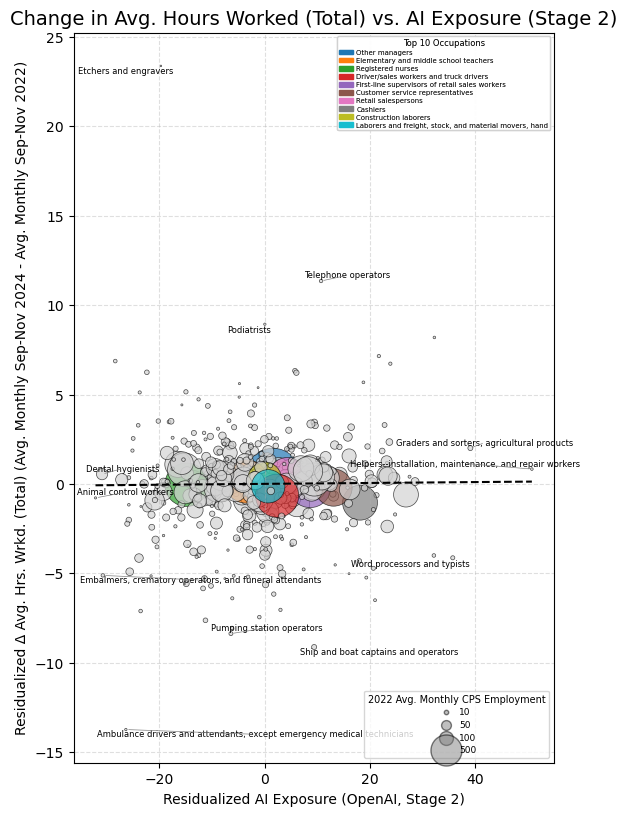

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
import matplotlib.patches as mpatches
import pandas as pd
import textwrap
import statsmodels.api as sm
import numpy as np

# Load data
df = pd.read_stata("Data/Cleaned/6M_residuals_for_plots.dta")

# Clean and prep
plot_df = df[['cps_code', 'cps_title', 'openai2_resid', 'd_ahrsworkt_resid', 'avg_monthly_emp']].dropna()
plot_df['cps_code'] = plot_df['cps_code'].astype(str)

# Top 10 occupations
top_cps_codes = ['440', '2310', '3255', '9130', '4700', '5240', '4760', '4720', '6260', '9620']
palette = sns.color_palette("tab10", len(top_cps_codes))
color_map = dict(zip(top_cps_codes, palette))

# Assign colors
plot_df['color'] = plot_df['cps_code'].apply(lambda x: color_map[x] if x in top_cps_codes else 'lightgray')

# Define edge outliers using axis extremes
edge_df = pd.concat([
    plot_df.nsmallest(3, 'openai2_resid'),
    plot_df.nlargest(3, 'openai2_resid'),
    plot_df.nsmallest(3, 'd_ahrsworkt_resid'),
    plot_df.nlargest(3, 'd_ahrsworkt_resid')
]).drop_duplicates()

# Label only those outliers
plot_df['edge_label'] = plot_df.apply(
    lambda row: row['cps_title'] if row['cps_title'] in edge_df['cps_title'].values else None,
    axis=1
)

# Create plot
fig, ax = plt.subplots(figsize=(8, 10))

# Bubble scatter
ax.scatter(
    plot_df['openai2_resid'],
    plot_df['d_ahrsworkt_resid'],
    s=plot_df['avg_monthly_emp'],
    color=plot_df['color'],
    alpha=0.7,
    edgecolors='black',
    linewidths=0.5
)

# Drop NA rows used for regression
dfw = plot_df.dropna(subset=['openai2_resid', 'd_ahrsworkt_resid', 'avg_monthly_emp'])

# Define X, y, and weights
X = sm.add_constant(dfw['openai2_resid'])
y = dfw['d_ahrsworkt_resid']
weights = dfw['avg_monthly_emp']

# Fit weighted least squares model
wls_model = sm.WLS(y, X, weights=weights)
results = wls_model.fit()

# Predict values for plotting the regression line
x_vals = np.linspace(dfw['openai2_resid'].min(), dfw['openai2_resid'].max(), 100)
X_pred = sm.add_constant(x_vals)
y_pred = results.predict(X_pred)

# Plot weighted regression line
ax.plot(x_vals, y_pred, color='black', linestyle='--', linewidth=1.5, label='Weighted Regression')
ax.legend()

# --- Bubble Size Legend (top right) ---
bubble_legend = [
    plt.scatter([], [], s=size, c='gray', alpha=0.5, edgecolors='k', label=f'{size:,}')
    for size in [10, 50, 100, 500]
]

bubble_legend_obj = ax.legend(
    handles=bubble_legend,
    title='2022 Avg. Monthly CPS Employment',
    loc='lower right',
    fontsize=6.5,
    title_fontsize=7,
    frameon=True,
    labelspacing=0.4,
    handletextpad=0.5,
    borderpad=0.4
)

# --- Occupation Color Legend (bottom right) ---
patches = [
    mpatches.Patch(color=color_map[code], label=plot_df[plot_df['cps_code'] == code]['cps_title'].iloc[0])
    for code in top_cps_codes
]

occupation_legend_obj = ax.legend(
    handles=patches,
    title='Top 10 Occupations',
    loc='upper right',
    fontsize=5,
    title_fontsize=6,
    frameon=True,
    labelspacing=0.3,
    handletextpad=0.4,
    borderpad=0.3,
    ncol=1
)

# Add both legends to plot
ax.add_artist(bubble_legend_obj)
ax.add_artist(occupation_legend_obj)



from adjustText import adjust_text

texts = []

# Create label texts directly *at the point* — let adjustText do all movement
for _, row in plot_df[plot_df['edge_label'].notnull()].iterrows():
    texts.append(
        ax.text(
            row['openai2_resid'],
            row['d_ahrsworkt_resid'],
            row['edge_label'],
            fontsize=6,
            ha='center',
            va='center'
        )
    )

# Adjust placement with proper arrows
adjust_text(
    texts,
    x=plot_df.loc[plot_df['edge_label'].notnull(), 'openai2_resid'],
    y=plot_df.loc[plot_df['edge_label'].notnull(), 'd_ahrsworkt_resid'],
    arrowprops=dict(
        arrowstyle='-', 
        color='gray', 
        lw=0.5,
        shrinkA=2,  # shrink arrowhead from text
        shrinkB=2   # shrink arrowhead from point
    ),
    expand_text=(1.2, 1.4),
    expand_points=(1.2, 1.4),
    ax=ax
)


# Final polish
ax.set_title("Change in Avg. Hours Worked (Total) vs. AI Exposure (Stage 2)", fontsize=14)
ax.set_xlabel("Residualized AI Exposure (OpenAI, Stage 2)")
ax.set_ylabel("Residualized Δ Avg. Hrs. Wrkd. (Total) (Avg. Monthly Sep-Nov 2024 - Avg. Monthly Sep-Nov 2022)")
ax.grid(True, linestyle='--', alpha=0.4)

fig.tight_layout()
fig.subplots_adjust(right=0.75, left=0.15, top=0.88, bottom=0.15)

# Save
plt.savefig("Output/April/Bubble3/Base_AHT_6MS2_OA.png", dpi=300, bbox_inches='tight')
plt.show()


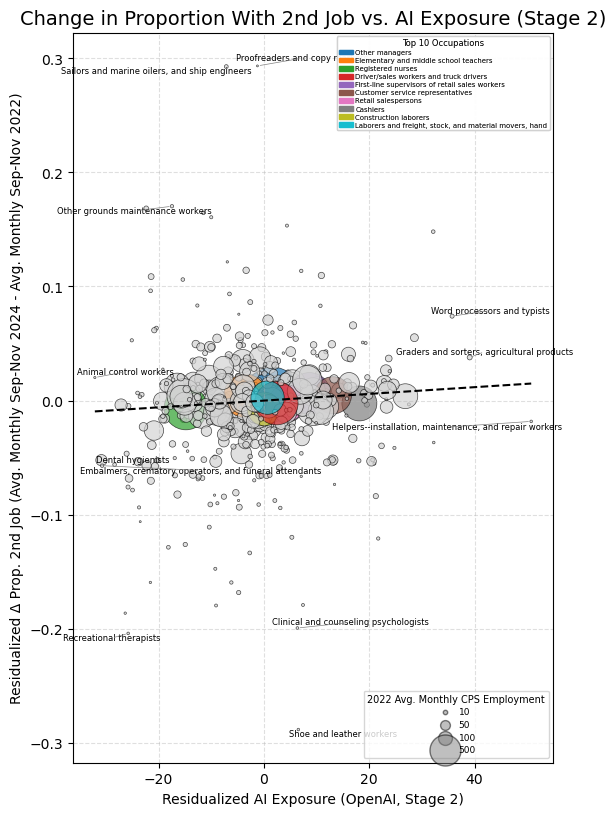

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
import matplotlib.patches as mpatches
import pandas as pd
import textwrap
import statsmodels.api as sm
import numpy as np

# Load data
df = pd.read_stata("Data/Cleaned/6M_residuals_for_plots.dta")

# Clean and prep
plot_df = df[['cps_code', 'cps_title', 'openai2_resid', 'd_other_job_resid', 'avg_monthly_emp']].dropna()
plot_df['cps_code'] = plot_df['cps_code'].astype(str)

# Top 10 occupations
top_cps_codes = ['440', '2310', '3255', '9130', '4700', '5240', '4760', '4720', '6260', '9620']
palette = sns.color_palette("tab10", len(top_cps_codes))
color_map = dict(zip(top_cps_codes, palette))

# Assign colors
plot_df['color'] = plot_df['cps_code'].apply(lambda x: color_map[x] if x in top_cps_codes else 'lightgray')

# Define edge outliers using axis extremes
edge_df = pd.concat([
    plot_df.nsmallest(3, 'openai2_resid'),
    plot_df.nlargest(3, 'openai2_resid'),
    plot_df.nsmallest(3, 'd_other_job_resid'),
    plot_df.nlargest(3, 'd_other_job_resid')
]).drop_duplicates()

# Label only those outliers
plot_df['edge_label'] = plot_df.apply(
    lambda row: row['cps_title'] if row['cps_title'] in edge_df['cps_title'].values else None,
    axis=1
)

# Create plot
fig, ax = plt.subplots(figsize=(8, 10))

# Bubble scatter
ax.scatter(
    plot_df['openai2_resid'],
    plot_df['d_other_job_resid'],
    s=plot_df['avg_monthly_emp'],
    color=plot_df['color'],
    alpha=0.7,
    edgecolors='black',
    linewidths=0.5
)

# Drop NA rows used for regression
dfw = plot_df.dropna(subset=['openai2_resid', 'd_other_job_resid', 'avg_monthly_emp'])

# Define X, y, and weights
X = sm.add_constant(dfw['openai2_resid'])
y = dfw['d_other_job_resid']
weights = dfw['avg_monthly_emp']

# Fit weighted least squares model
wls_model = sm.WLS(y, X, weights=weights)
results = wls_model.fit()

# Predict values for plotting the regression line
x_vals = np.linspace(dfw['openai2_resid'].min(), dfw['openai2_resid'].max(), 100)
X_pred = sm.add_constant(x_vals)
y_pred = results.predict(X_pred)

# Plot weighted regression line
ax.plot(x_vals, y_pred, color='black', linestyle='--', linewidth=1.5, label='Weighted Regression')
ax.legend()

# --- Bubble Size Legend (top right) ---
bubble_legend = [
    plt.scatter([], [], s=size, c='gray', alpha=0.5, edgecolors='k', label=f'{size:,}')
    for size in [10, 50, 100, 500]
]

bubble_legend_obj = ax.legend(
    handles=bubble_legend,
    title='2022 Avg. Monthly CPS Employment',
    loc='lower right',
    fontsize=6.5,
    title_fontsize=7,
    frameon=True,
    labelspacing=0.4,
    handletextpad=0.5,
    borderpad=0.4
)

# --- Occupation Color Legend (bottom right) ---
patches = [
    mpatches.Patch(color=color_map[code], label=plot_df[plot_df['cps_code'] == code]['cps_title'].iloc[0])
    for code in top_cps_codes
]

occupation_legend_obj = ax.legend(
    handles=patches,
    title='Top 10 Occupations',
    loc='upper right',
    fontsize=5,
    title_fontsize=6,
    frameon=True,
    labelspacing=0.3,
    handletextpad=0.4,
    borderpad=0.3,
    ncol=1
)

# Add both legends to plot
ax.add_artist(bubble_legend_obj)
ax.add_artist(occupation_legend_obj)



from adjustText import adjust_text

texts = []

# Create label texts directly *at the point* — let adjustText do all movement
for _, row in plot_df[plot_df['edge_label'].notnull()].iterrows():
    texts.append(
        ax.text(
            row['openai2_resid'],
            row['d_other_job_resid'],
            row['edge_label'],
            fontsize=6,
            ha='center',
            va='center'
        )
    )

# Adjust placement with proper arrows
adjust_text(
    texts,
    x=plot_df.loc[plot_df['edge_label'].notnull(), 'openai2_resid'],
    y=plot_df.loc[plot_df['edge_label'].notnull(), 'd_other_job_resid'],
    arrowprops=dict(
        arrowstyle='-', 
        color='gray', 
        lw=0.5,
        shrinkA=2,  # shrink arrowhead from text
        shrinkB=2   # shrink arrowhead from point
    ),
    expand_text=(1.2, 1.4),
    expand_points=(1.2, 1.4),
    ax=ax
)


# Final polish
ax.set_title("Change in Proportion With 2nd Job vs. AI Exposure (Stage 2)", fontsize=14)
ax.set_xlabel("Residualized AI Exposure (OpenAI, Stage 2)")
ax.set_ylabel("Residualized Δ Prop. 2nd Job (Avg. Monthly Sep-Nov 2024 - Avg. Monthly Sep-Nov 2022)")
ax.grid(True, linestyle='--', alpha=0.4)

fig.tight_layout()
fig.subplots_adjust(right=0.75, left=0.15, top=0.88, bottom=0.15)

# Save
plt.savefig("Output/April/Bubble3/Base_OJ_6MS2_OA.png", dpi=300, bbox_inches='tight')
plt.show()


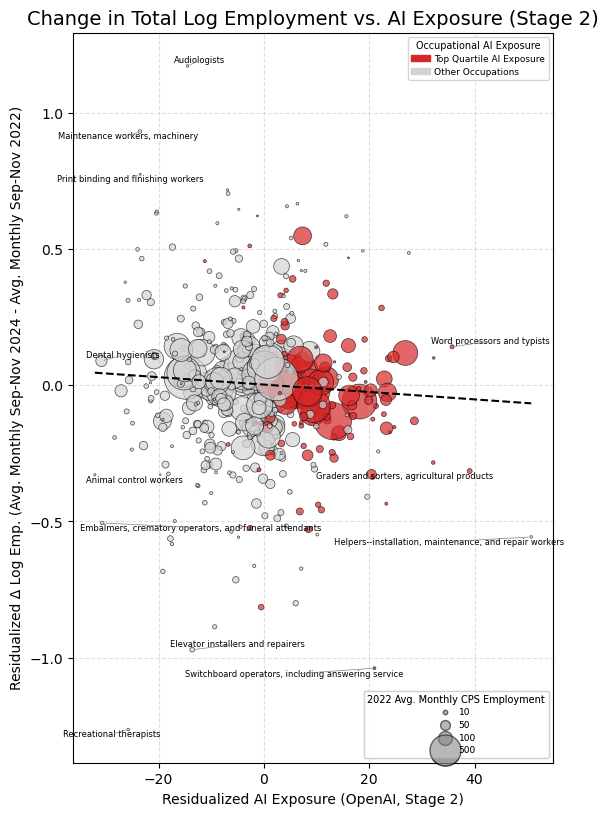

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
import matplotlib.patches as mpatches
import pandas as pd
import textwrap
import statsmodels.api as sm
import numpy as np

# Load data
df = pd.read_stata("Data/Cleaned/6M_residuals_for_plots.dta")

# Clean and prep
plot_df = df[['cps_code', 'cps_title', 'openai2_resid', 'd_log_emp_resid', 'avg_monthly_emp', 'DQ4_openai2']].dropna()
plot_df['cps_code'] = plot_df['cps_code'].astype(str)

# Assign colors based on exposure quartile
plot_df['color'] = plot_df['DQ4_openai2'].apply(lambda x: 'tab:red' if x == 1 else 'lightgray')

# Define edge outliers using axis extremes
edge_df = pd.concat([
    plot_df.nsmallest(3, 'openai2_resid'),
    plot_df.nlargest(3, 'openai2_resid'),
    plot_df.nsmallest(3, 'd_log_emp_resid'),
    plot_df.nlargest(3, 'd_log_emp_resid')
]).drop_duplicates()

# Label only those outliers
plot_df['edge_label'] = plot_df.apply(
    lambda row: row['cps_title'] if row['cps_title'] in edge_df['cps_title'].values else None,
    axis=1
)

# Create plot
fig, ax = plt.subplots(figsize=(8, 10))

# Bubble scatter
ax.scatter(
    plot_df['openai2_resid'],
    plot_df['d_log_emp_resid'],
    s=plot_df['avg_monthly_emp'],
    color=plot_df['color'],
    alpha=0.7,
    edgecolors='black',
    linewidths=0.5
)

# Drop NA rows used for regression
dfw = plot_df.dropna(subset=['openai2_resid', 'd_log_emp_resid', 'avg_monthly_emp'])

# Define X, y, and weights
X = sm.add_constant(dfw['openai2_resid'])
y = dfw['d_log_emp_resid']
weights = dfw['avg_monthly_emp']

# Fit weighted least squares model
wls_model = sm.WLS(y, X, weights=weights)
results = wls_model.fit()

# Predict values for plotting the regression line
x_vals = np.linspace(dfw['openai2_resid'].min(), dfw['openai2_resid'].max(), 100)
X_pred = sm.add_constant(x_vals)
y_pred = results.predict(X_pred)

# Plot weighted regression line
ax.plot(x_vals, y_pred, color='black', linestyle='--', linewidth=1.5, label='Weighted Regression')
ax.legend()

import matplotlib.patches as mpatches

# --- Legend: Exposure quartile (bottom right) ---
exposure_patches = [
    mpatches.Patch(color='tab:red', label='Top Quartile AI Exposure'),
    mpatches.Patch(color='lightgray', label='Other Occupations')
]

exposure_legend = ax.legend(
    handles=exposure_patches,
    title='Occupational AI Exposure',
    loc='upper right',
    fontsize=6.5,
    title_fontsize=7,
    frameon=True,
    labelspacing=0.4,
    handletextpad=0.5,
    borderpad=0.4,
    ncol=1
)

# --- Legend: Bubble size (top right) ---
bubble_legend = [
    plt.scatter([], [], s=size, c='gray', alpha=0.5, edgecolors='k', label=f'{size:,}')
    for size in [10, 50, 100, 500]
]

bubble_legend = ax.legend(
    handles=bubble_legend,
    title='2022 Avg. Monthly CPS Employment',
    loc='lower right',
    fontsize=6.5,
    title_fontsize=7,
    frameon=True,
    labelspacing=0.4,
    handletextpad=0.5,
    borderpad=0.4
)

# Add both legends to the plot
ax.add_artist(exposure_legend)
ax.add_artist(bubble_legend)


# Label extreme points
texts = []
for _, row in plot_df[plot_df['edge_label'].notnull()].iterrows():
    texts.append(
        ax.text(
            row['openai2_resid'],
            row['d_log_emp_resid'],
            row['edge_label'],
            fontsize=6,
            ha='center',
            va='center'
        )
    )

adjust_text(
    texts,
    x=plot_df.loc[plot_df['edge_label'].notnull(), 'openai2_resid'],
    y=plot_df.loc[plot_df['edge_label'].notnull(), 'd_log_emp_resid'],
    arrowprops=dict(
        arrowstyle='-', 
        color='gray', 
        lw=0.5,
        shrinkA=2,
        shrinkB=2
    ),
    expand_text=(1.2, 1.4),
    expand_points=(1.2, 1.4),
    ax=ax
)

# Final polish
ax.set_title("Change in Total Log Employment vs. AI Exposure (Stage 2)", fontsize=14)
ax.set_xlabel("Residualized AI Exposure (OpenAI, Stage 2)")
ax.set_ylabel("Residualized Δ Log Emp. (Avg. Monthly Sep-Nov 2024 - Avg. Monthly Sep-Nov 2022)")
ax.grid(True, linestyle='--', alpha=0.4)

fig.tight_layout()
fig.subplots_adjust(right=0.75, left=0.15, top=0.88, bottom=0.15)

# Save
plt.savefig("Output/April/Bubble3/QC_EMP_6MS2_OA.png", dpi=300, bbox_inches='tight')
plt.show()


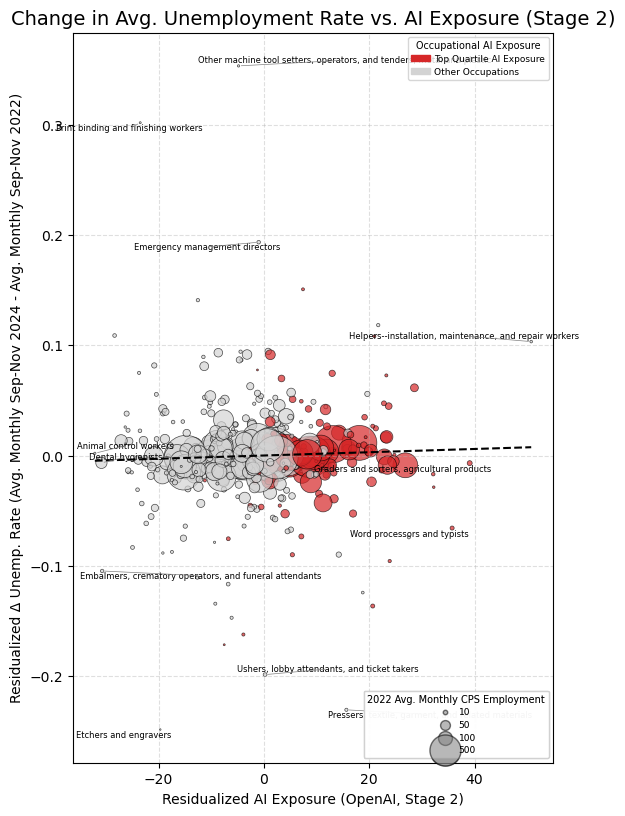

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
import matplotlib.patches as mpatches
import pandas as pd
import textwrap
import statsmodels.api as sm
import numpy as np

# Load data
df = pd.read_stata("Data/Cleaned/6M_residuals_for_plots.dta")

# Clean and prep
plot_df = df[['cps_code', 'cps_title', 'openai2_resid', 'd_unemp_rate_resid', 'avg_monthly_emp', 'DQ4_openai2']].dropna()
plot_df['cps_code'] = plot_df['cps_code'].astype(str)

# Assign colors based on exposure quartile
plot_df['color'] = plot_df['DQ4_openai2'].apply(lambda x: 'tab:red' if x == 1 else 'lightgray')

# Define edge outliers using axis extremes
edge_df = pd.concat([
    plot_df.nsmallest(3, 'openai2_resid'),
    plot_df.nlargest(3, 'openai2_resid'),
    plot_df.nsmallest(3, 'd_unemp_rate_resid'),
    plot_df.nlargest(3, 'd_unemp_rate_resid')
]).drop_duplicates()

# Label only those outliers
plot_df['edge_label'] = plot_df.apply(
    lambda row: row['cps_title'] if row['cps_title'] in edge_df['cps_title'].values else None,
    axis=1
)

# Create plot
fig, ax = plt.subplots(figsize=(8, 10))

# Bubble scatter
ax.scatter(
    plot_df['openai2_resid'],
    plot_df['d_unemp_rate_resid'],
    s=plot_df['avg_monthly_emp'],
    color=plot_df['color'],
    alpha=0.7,
    edgecolors='black',
    linewidths=0.5
)

# Drop NA rows used for regression
dfw = plot_df.dropna(subset=['openai2_resid', 'd_unemp_rate_resid', 'avg_monthly_emp'])

# Define X, y, and weights
X = sm.add_constant(dfw['openai2_resid'])
y = dfw['d_unemp_rate_resid']
weights = dfw['avg_monthly_emp']

# Fit weighted least squares model
wls_model = sm.WLS(y, X, weights=weights)
results = wls_model.fit()

# Predict values for plotting the regression line
x_vals = np.linspace(dfw['openai2_resid'].min(), dfw['openai2_resid'].max(), 100)
X_pred = sm.add_constant(x_vals)
y_pred = results.predict(X_pred)

# Plot weighted regression line
ax.plot(x_vals, y_pred, color='black', linestyle='--', linewidth=1.5, label='Weighted Regression')
ax.legend()

# --- Legend: Exposure quartile (bottom right) ---
exposure_patches = [
    mpatches.Patch(color='tab:red', label='Top Quartile AI Exposure'),
    mpatches.Patch(color='lightgray', label='Other Occupations')
]

exposure_legend = ax.legend(
    handles=exposure_patches,
    title='Occupational AI Exposure',
    loc='upper right',
    fontsize=6.5,
    title_fontsize=7,
    frameon=True,
    labelspacing=0.4,
    handletextpad=0.5,
    borderpad=0.4,
    ncol=1
)

# --- Legend: Bubble size (top right) ---
bubble_legend = [
    plt.scatter([], [], s=size, c='gray', alpha=0.5, edgecolors='k', label=f'{size:,}')
    for size in [10, 50, 100, 500]
]

bubble_legend = ax.legend(
    handles=bubble_legend,
    title='2022 Avg. Monthly CPS Employment',
    loc='lower right',
    fontsize=6.5,
    title_fontsize=7,
    frameon=True,
    labelspacing=0.4,
    handletextpad=0.5,
    borderpad=0.4
)

# Add both legends to the plot
ax.add_artist(exposure_legend)
ax.add_artist(bubble_legend)



# Label extreme points
texts = []
for _, row in plot_df[plot_df['edge_label'].notnull()].iterrows():
    texts.append(
        ax.text(
            row['openai2_resid'],
            row['d_unemp_rate_resid'],
            row['edge_label'],
            fontsize=6,
            ha='center',
            va='center'
        )
    )

adjust_text(
    texts,
    x=plot_df.loc[plot_df['edge_label'].notnull(), 'openai2_resid'],
    y=plot_df.loc[plot_df['edge_label'].notnull(), 'd_unemp_rate_resid'],
    arrowprops=dict(
        arrowstyle='-', 
        color='gray', 
        lw=0.5,
        shrinkA=2,
        shrinkB=2
    ),
    expand_text=(1.2, 1.4),
    expand_points=(1.2, 1.4),
    ax=ax
)

# Final polish
ax.set_title("Change in Avg. Unemployment Rate vs. AI Exposure (Stage 2)", fontsize=14)
ax.set_xlabel("Residualized AI Exposure (OpenAI, Stage 2)")
ax.set_ylabel("Residualized Δ Unemp. Rate (Avg. Monthly Sep-Nov 2024 - Avg. Monthly Sep-Nov 2022)")
ax.grid(True, linestyle='--', alpha=0.4)

fig.tight_layout()
fig.subplots_adjust(right=0.75, left=0.15, top=0.88, bottom=0.15)

# Save
plt.savefig("Output/April/Bubble3/QC_UNEMP_6MS2_OA.png", dpi=300, bbox_inches='tight')
plt.show()


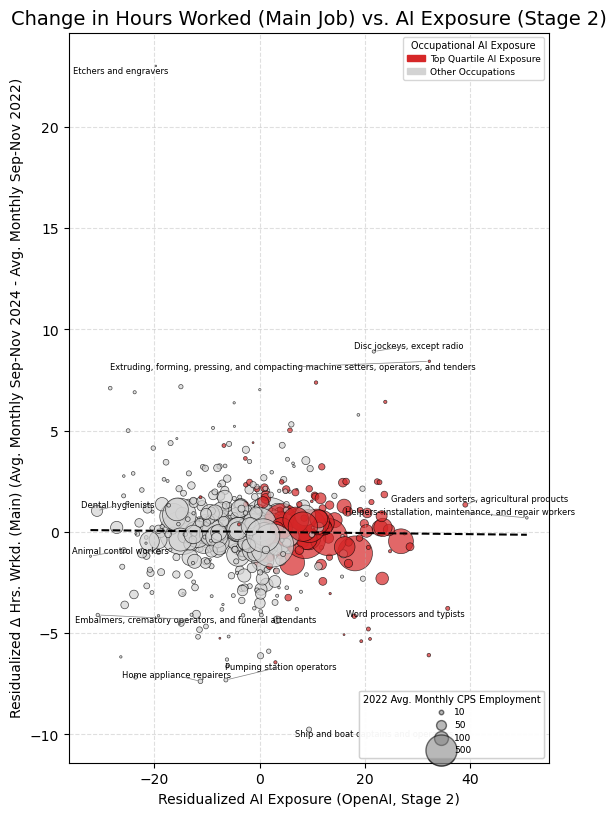

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
import matplotlib.patches as mpatches
import pandas as pd
import textwrap
import statsmodels.api as sm
import numpy as np

# Load data
df = pd.read_stata("Data/Cleaned/6M_residuals_for_plots.dta")

# Clean and prep
plot_df = df[['cps_code', 'cps_title', 'openai2_resid', 'd_ahrswork1_resid', 'avg_monthly_emp', 'DQ4_openai2']].dropna()
plot_df['cps_code'] = plot_df['cps_code'].astype(str)

# Assign colors based on exposure quartile
plot_df['color'] = plot_df['DQ4_openai2'].apply(lambda x: 'tab:red' if x == 1 else 'lightgray')

# Define edge outliers using axis extremes
edge_df = pd.concat([
    plot_df.nsmallest(3, 'openai2_resid'),
    plot_df.nlargest(3, 'openai2_resid'),
    plot_df.nsmallest(3, 'd_ahrswork1_resid'),
    plot_df.nlargest(3, 'd_ahrswork1_resid')
]).drop_duplicates()

# Label only those outliers
plot_df['edge_label'] = plot_df.apply(
    lambda row: row['cps_title'] if row['cps_title'] in edge_df['cps_title'].values else None,
    axis=1
)

# Create plot
fig, ax = plt.subplots(figsize=(8, 10))

# Bubble scatter
ax.scatter(
    plot_df['openai2_resid'],
    plot_df['d_ahrswork1_resid'],
    s=plot_df['avg_monthly_emp'],
    color=plot_df['color'],
    alpha=0.7,
    edgecolors='black',
    linewidths=0.5
)

# Drop NA rows used for regression
dfw = plot_df.dropna(subset=['openai2_resid', 'd_ahrswork1_resid', 'avg_monthly_emp'])

# Define X, y, and weights
X = sm.add_constant(dfw['openai2_resid'])
y = dfw['d_ahrswork1_resid']
weights = dfw['avg_monthly_emp']

# Fit weighted least squares model
wls_model = sm.WLS(y, X, weights=weights)
results = wls_model.fit()

# Predict values for plotting the regression line
x_vals = np.linspace(dfw['openai2_resid'].min(), dfw['openai2_resid'].max(), 100)
X_pred = sm.add_constant(x_vals)
y_pred = results.predict(X_pred)

# Plot weighted regression line
ax.plot(x_vals, y_pred, color='black', linestyle='--', linewidth=1.5, label='Weighted Regression')
ax.legend()

# --- Legend: Exposure quartile (bottom right) ---
exposure_patches = [
    mpatches.Patch(color='tab:red', label='Top Quartile AI Exposure'),
    mpatches.Patch(color='lightgray', label='Other Occupations')
]

exposure_legend = ax.legend(
    handles=exposure_patches,
    title='Occupational AI Exposure',
    loc='upper right',
    fontsize=6.5,
    title_fontsize=7,
    frameon=True,
    labelspacing=0.4,
    handletextpad=0.5,
    borderpad=0.4,
    ncol=1
)

# --- Legend: Bubble size (top right) ---
bubble_legend = [
    plt.scatter([], [], s=size, c='gray', alpha=0.5, edgecolors='k', label=f'{size:,}')
    for size in [10, 50, 100, 500]
]

bubble_legend = ax.legend(
    handles=bubble_legend,
    title='2022 Avg. Monthly CPS Employment',
    loc='lower right',
    fontsize=6.5,
    title_fontsize=7,
    frameon=True,
    labelspacing=0.4,
    handletextpad=0.5,
    borderpad=0.4
)

# Add both legends to the plot
ax.add_artist(exposure_legend)
ax.add_artist(bubble_legend)



# Label extreme points
texts = []
for _, row in plot_df[plot_df['edge_label'].notnull()].iterrows():
    texts.append(
        ax.text(
            row['openai2_resid'],
            row['d_ahrswork1_resid'],
            row['edge_label'],
            fontsize=6,
            ha='center',
            va='center'
        )
    )

adjust_text(
    texts,
    x=plot_df.loc[plot_df['edge_label'].notnull(), 'openai2_resid'],
    y=plot_df.loc[plot_df['edge_label'].notnull(), 'd_ahrswork1_resid'],
    arrowprops=dict(
        arrowstyle='-', 
        color='gray', 
        lw=0.5,
        shrinkA=2,
        shrinkB=2
    ),
    expand_text=(1.2, 1.4),
    expand_points=(1.2, 1.4),
    ax=ax
)

# Final polish
ax.set_title("Change in Hours Worked (Main Job) vs. AI Exposure (Stage 2)", fontsize=14)
ax.set_xlabel("Residualized AI Exposure (OpenAI, Stage 2)")
ax.set_ylabel("Residualized Δ Hrs. Wrkd. (Main) (Avg. Monthly Sep-Nov 2024 - Avg. Monthly Sep-Nov 2022)")
ax.grid(True, linestyle='--', alpha=0.4)

fig.tight_layout()
fig.subplots_adjust(right=0.75, left=0.15, top=0.88, bottom=0.15)

# Save
plt.savefig("Output/April/Bubble3/QC_AH1_6MS2_OA.png", dpi=300, bbox_inches='tight')
plt.show()


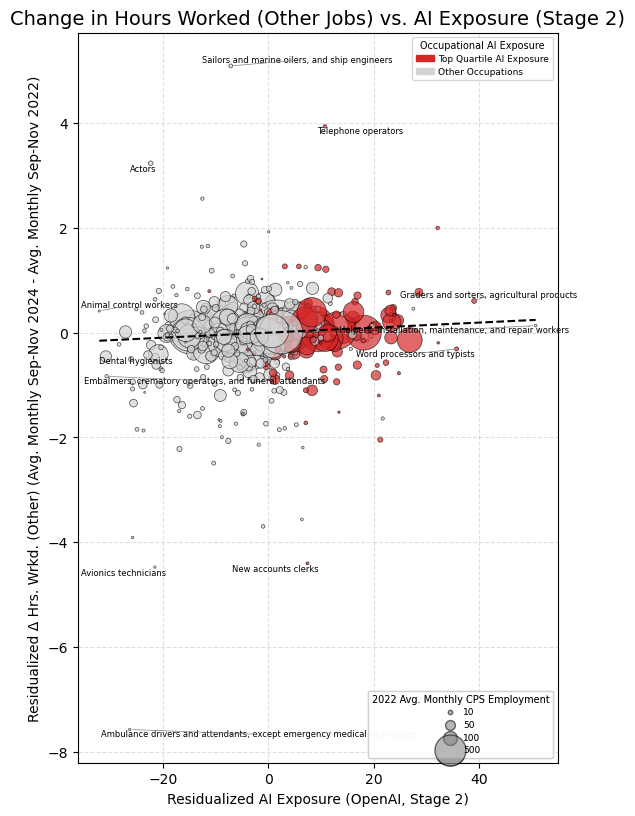

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
import matplotlib.patches as mpatches
import pandas as pd
import textwrap
import statsmodels.api as sm
import numpy as np

# Load data
df = pd.read_stata("Data/Cleaned/6M_residuals_for_plots.dta")

# Clean and prep
plot_df = df[['cps_code', 'cps_title', 'openai2_resid', 'd_ahrswork2_resid', 'avg_monthly_emp', 'DQ4_openai2']].dropna()
plot_df['cps_code'] = plot_df['cps_code'].astype(str)

# Assign colors based on exposure quartile
plot_df['color'] = plot_df['DQ4_openai2'].apply(lambda x: 'tab:red' if x == 1 else 'lightgray')

# Define edge outliers using axis extremes
edge_df = pd.concat([
    plot_df.nsmallest(3, 'openai2_resid'),
    plot_df.nlargest(3, 'openai2_resid'),
    plot_df.nsmallest(3, 'd_ahrswork2_resid'),
    plot_df.nlargest(3, 'd_ahrswork2_resid')
]).drop_duplicates()

# Label only those outliers
plot_df['edge_label'] = plot_df.apply(
    lambda row: row['cps_title'] if row['cps_title'] in edge_df['cps_title'].values else None,
    axis=1
)

# Create plot
fig, ax = plt.subplots(figsize=(8, 10))

# Bubble scatter
ax.scatter(
    plot_df['openai2_resid'],
    plot_df['d_ahrswork2_resid'],
    s=plot_df['avg_monthly_emp'],
    color=plot_df['color'],
    alpha=0.7,
    edgecolors='black',
    linewidths=0.5
)

# Drop NA rows used for regression
dfw = plot_df.dropna(subset=['openai2_resid', 'd_ahrswork2_resid', 'avg_monthly_emp'])

# Define X, y, and weights
X = sm.add_constant(dfw['openai2_resid'])
y = dfw['d_ahrswork2_resid']
weights = dfw['avg_monthly_emp']

# Fit weighted least squares model
wls_model = sm.WLS(y, X, weights=weights)
results = wls_model.fit()

# Predict values for plotting the regression line
x_vals = np.linspace(dfw['openai2_resid'].min(), dfw['openai2_resid'].max(), 100)
X_pred = sm.add_constant(x_vals)
y_pred = results.predict(X_pred)

# Plot weighted regression line
ax.plot(x_vals, y_pred, color='black', linestyle='--', linewidth=1.5, label='Weighted Regression')
ax.legend()

# --- Legend: Exposure quartile (bottom right) ---
exposure_patches = [
    mpatches.Patch(color='tab:red', label='Top Quartile AI Exposure'),
    mpatches.Patch(color='lightgray', label='Other Occupations')
]

exposure_legend = ax.legend(
    handles=exposure_patches,
    title='Occupational AI Exposure',
    loc='upper right',
    fontsize=6.5,
    title_fontsize=7,
    frameon=True,
    labelspacing=0.4,
    handletextpad=0.5,
    borderpad=0.4,
    ncol=1
)

# --- Legend: Bubble size (top right) ---
bubble_legend = [
    plt.scatter([], [], s=size, c='gray', alpha=0.5, edgecolors='k', label=f'{size:,}')
    for size in [10, 50, 100, 500]
]

bubble_legend = ax.legend(
    handles=bubble_legend,
    title='2022 Avg. Monthly CPS Employment',
    loc='lower right',
    fontsize=6.5,
    title_fontsize=7,
    frameon=True,
    labelspacing=0.4,
    handletextpad=0.5,
    borderpad=0.4
)

# Add both legends to the plot
ax.add_artist(exposure_legend)
ax.add_artist(bubble_legend)



# Label extreme points
texts = []
for _, row in plot_df[plot_df['edge_label'].notnull()].iterrows():
    texts.append(
        ax.text(
            row['openai2_resid'],
            row['d_ahrswork2_resid'],
            row['edge_label'],
            fontsize=6,
            ha='center',
            va='center'
        )
    )

adjust_text(
    texts,
    x=plot_df.loc[plot_df['edge_label'].notnull(), 'openai2_resid'],
    y=plot_df.loc[plot_df['edge_label'].notnull(), 'd_ahrswork2_resid'],
    arrowprops=dict(
        arrowstyle='-', 
        color='gray', 
        lw=0.5,
        shrinkA=2,
        shrinkB=2
    ),
    expand_text=(1.2, 1.4),
    expand_points=(1.2, 1.4),
    ax=ax
)

# Final polish
ax.set_title("Change in Hours Worked (Other Jobs) vs. AI Exposure (Stage 2)", fontsize=14)
ax.set_xlabel("Residualized AI Exposure (OpenAI, Stage 2)")
ax.set_ylabel("Residualized Δ Hrs. Wrkd. (Other) (Avg. Monthly Sep-Nov 2024 - Avg. Monthly Sep-Nov 2022)")
ax.grid(True, linestyle='--', alpha=0.4)

fig.tight_layout()
fig.subplots_adjust(right=0.75, left=0.15, top=0.88, bottom=0.15)

# Save
plt.savefig("Output/April/Bubble3/QC_AH2_6MS2_OA.png", dpi=300, bbox_inches='tight')
plt.show()


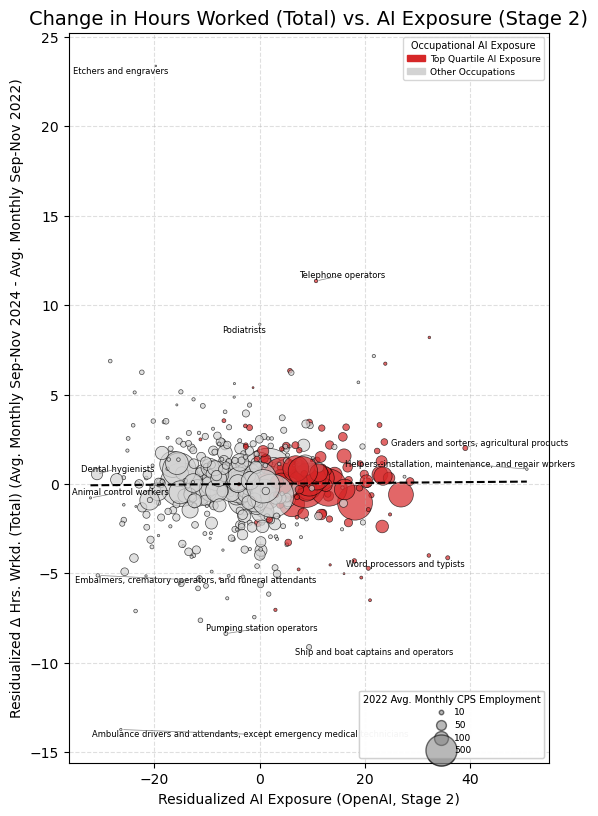

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
import matplotlib.patches as mpatches
import pandas as pd
import textwrap
import statsmodels.api as sm
import numpy as np

# Load data
df = pd.read_stata("Data/Cleaned/6M_residuals_for_plots.dta")

# Clean and prep
plot_df = df[['cps_code', 'cps_title', 'openai2_resid', 'd_ahrsworkt_resid', 'avg_monthly_emp', 'DQ4_openai2']].dropna()
plot_df['cps_code'] = plot_df['cps_code'].astype(str)

# Assign colors based on exposure quartile
plot_df['color'] = plot_df['DQ4_openai2'].apply(lambda x: 'tab:red' if x == 1 else 'lightgray')

# Define edge outliers using axis extremes
edge_df = pd.concat([
    plot_df.nsmallest(3, 'openai2_resid'),
    plot_df.nlargest(3, 'openai2_resid'),
    plot_df.nsmallest(3, 'd_ahrsworkt_resid'),
    plot_df.nlargest(3, 'd_ahrsworkt_resid')
]).drop_duplicates()

# Label only those outliers
plot_df['edge_label'] = plot_df.apply(
    lambda row: row['cps_title'] if row['cps_title'] in edge_df['cps_title'].values else None,
    axis=1
)

# Create plot
fig, ax = plt.subplots(figsize=(8, 10))

# Bubble scatter
ax.scatter(
    plot_df['openai2_resid'],
    plot_df['d_ahrsworkt_resid'],
    s=plot_df['avg_monthly_emp'],
    color=plot_df['color'],
    alpha=0.7,
    edgecolors='black',
    linewidths=0.5
)

# Drop NA rows used for regression
dfw = plot_df.dropna(subset=['openai2_resid', 'd_ahrsworkt_resid', 'avg_monthly_emp'])

# Define X, y, and weights
X = sm.add_constant(dfw['openai2_resid'])
y = dfw['d_ahrsworkt_resid']
weights = dfw['avg_monthly_emp']

# Fit weighted least squares model
wls_model = sm.WLS(y, X, weights=weights)
results = wls_model.fit()

# Predict values for plotting the regression line
x_vals = np.linspace(dfw['openai2_resid'].min(), dfw['openai2_resid'].max(), 100)
X_pred = sm.add_constant(x_vals)
y_pred = results.predict(X_pred)

# Plot weighted regression line
ax.plot(x_vals, y_pred, color='black', linestyle='--', linewidth=1.5, label='Weighted Regression')
ax.legend()

# --- Legend: Exposure quartile (bottom right) ---
exposure_patches = [
    mpatches.Patch(color='tab:red', label='Top Quartile AI Exposure'),
    mpatches.Patch(color='lightgray', label='Other Occupations')
]

exposure_legend = ax.legend(
    handles=exposure_patches,
    title='Occupational AI Exposure',
    loc='upper right',
    fontsize=6.5,
    title_fontsize=7,
    frameon=True,
    labelspacing=0.4,
    handletextpad=0.5,
    borderpad=0.4,
    ncol=1
)

# --- Legend: Bubble size (top right) ---
bubble_legend = [
    plt.scatter([], [], s=size, c='gray', alpha=0.5, edgecolors='k', label=f'{size:,}')
    for size in [10, 50, 100, 500]
]

bubble_legend = ax.legend(
    handles=bubble_legend,
    title='2022 Avg. Monthly CPS Employment',
    loc='lower right',
    fontsize=6.5,
    title_fontsize=7,
    frameon=True,
    labelspacing=0.4,
    handletextpad=0.5,
    borderpad=0.4
)

# Add both legends to the plot
ax.add_artist(exposure_legend)
ax.add_artist(bubble_legend)


# Label extreme points
texts = []
for _, row in plot_df[plot_df['edge_label'].notnull()].iterrows():
    texts.append(
        ax.text(
            row['openai2_resid'],
            row['d_ahrsworkt_resid'],
            row['edge_label'],
            fontsize=6,
            ha='center',
            va='center'
        )
    )

adjust_text(
    texts,
    x=plot_df.loc[plot_df['edge_label'].notnull(), 'openai2_resid'],
    y=plot_df.loc[plot_df['edge_label'].notnull(), 'd_ahrsworkt_resid'],
    arrowprops=dict(
        arrowstyle='-', 
        color='gray', 
        lw=0.5,
        shrinkA=2,
        shrinkB=2
    ),
    expand_text=(1.2, 1.4),
    expand_points=(1.2, 1.4),
    ax=ax
)

# Final polish
ax.set_title("Change in Hours Worked (Total) vs. AI Exposure (Stage 2)", fontsize=14)
ax.set_xlabel("Residualized AI Exposure (OpenAI, Stage 2)")
ax.set_ylabel("Residualized Δ Hrs. Wrkd. (Total) (Avg. Monthly Sep-Nov 2024 - Avg. Monthly Sep-Nov 2022)")
ax.grid(True, linestyle='--', alpha=0.4)

fig.tight_layout()
fig.subplots_adjust(right=0.75, left=0.15, top=0.88, bottom=0.15)

# Save
plt.savefig("Output/April/Bubble3/QC_AHT_6MS2_OA.png", dpi=300, bbox_inches='tight')
plt.show()


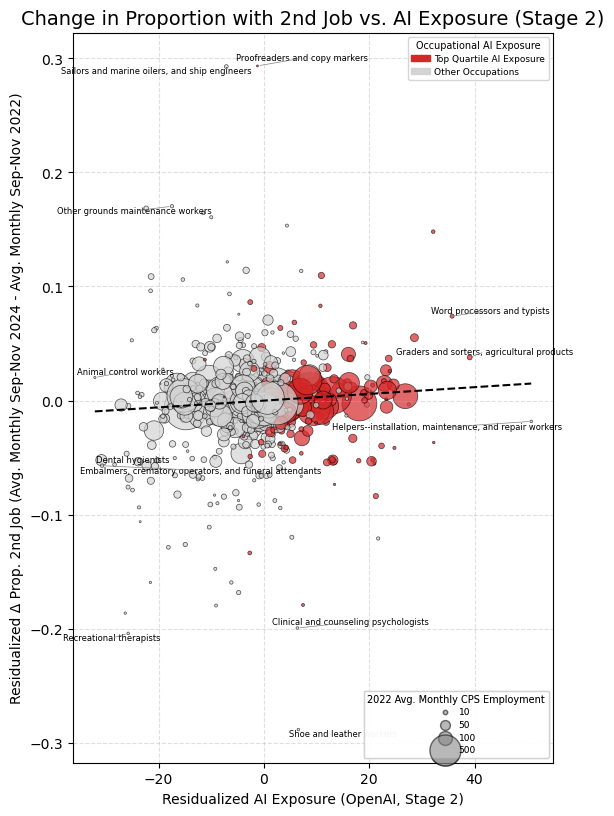

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
import matplotlib.patches as mpatches
import pandas as pd
import textwrap
import statsmodels.api as sm
import numpy as np

# Load data
df = pd.read_stata("Data/Cleaned/6M_residuals_for_plots.dta")

# Clean and prep
plot_df = df[['cps_code', 'cps_title', 'openai2_resid', 'd_other_job_resid', 'avg_monthly_emp', 'DQ4_openai2']].dropna()
plot_df['cps_code'] = plot_df['cps_code'].astype(str)

# Assign colors based on exposure quartile
plot_df['color'] = plot_df['DQ4_openai2'].apply(lambda x: 'tab:red' if x == 1 else 'lightgray')

# Define edge outliers using axis extremes
edge_df = pd.concat([
    plot_df.nsmallest(3, 'openai2_resid'),
    plot_df.nlargest(3, 'openai2_resid'),
    plot_df.nsmallest(3, 'd_other_job_resid'),
    plot_df.nlargest(3, 'd_other_job_resid')
]).drop_duplicates()

# Label only those outliers
plot_df['edge_label'] = plot_df.apply(
    lambda row: row['cps_title'] if row['cps_title'] in edge_df['cps_title'].values else None,
    axis=1
)

# Create plot
fig, ax = plt.subplots(figsize=(8, 10))

# Bubble scatter
ax.scatter(
    plot_df['openai2_resid'],
    plot_df['d_other_job_resid'],
    s=plot_df['avg_monthly_emp'],
    color=plot_df['color'],
    alpha=0.7,
    edgecolors='black',
    linewidths=0.5
)

# Drop NA rows used for regression
dfw = plot_df.dropna(subset=['openai2_resid', 'd_other_job_resid', 'avg_monthly_emp'])

# Define X, y, and weights
X = sm.add_constant(dfw['openai2_resid'])
y = dfw['d_other_job_resid']
weights = dfw['avg_monthly_emp']

# Fit weighted least squares model
wls_model = sm.WLS(y, X, weights=weights)
results = wls_model.fit()

# Predict values for plotting the regression line
x_vals = np.linspace(dfw['openai2_resid'].min(), dfw['openai2_resid'].max(), 100)
X_pred = sm.add_constant(x_vals)
y_pred = results.predict(X_pred)

# Plot weighted regression line
ax.plot(x_vals, y_pred, color='black', linestyle='--', linewidth=1.5, label='Weighted Regression')
ax.legend()

# --- Legend: Exposure quartile (bottom right) ---
exposure_patches = [
    mpatches.Patch(color='tab:red', label='Top Quartile AI Exposure'),
    mpatches.Patch(color='lightgray', label='Other Occupations')
]

exposure_legend = ax.legend(
    handles=exposure_patches,
    title='Occupational AI Exposure',
    loc='upper right',
    fontsize=6.5,
    title_fontsize=7,
    frameon=True,
    labelspacing=0.4,
    handletextpad=0.5,
    borderpad=0.4,
    ncol=1
)

# --- Legend: Bubble size (top right) ---
bubble_legend = [
    plt.scatter([], [], s=size, c='gray', alpha=0.5, edgecolors='k', label=f'{size:,}')
    for size in [10, 50, 100, 500]
]

bubble_legend = ax.legend(
    handles=bubble_legend,
    title='2022 Avg. Monthly CPS Employment',
    loc='lower right',
    fontsize=6.5,
    title_fontsize=7,
    frameon=True,
    labelspacing=0.4,
    handletextpad=0.5,
    borderpad=0.4
)

# Add both legends to the plot
ax.add_artist(exposure_legend)
ax.add_artist(bubble_legend)



# Label extreme points
texts = []
for _, row in plot_df[plot_df['edge_label'].notnull()].iterrows():
    texts.append(
        ax.text(
            row['openai2_resid'],
            row['d_other_job_resid'],
            row['edge_label'],
            fontsize=6,
            ha='center',
            va='center'
        )
    )

adjust_text(
    texts,
    x=plot_df.loc[plot_df['edge_label'].notnull(), 'openai2_resid'],
    y=plot_df.loc[plot_df['edge_label'].notnull(), 'd_other_job_resid'],
    arrowprops=dict(
        arrowstyle='-', 
        color='gray', 
        lw=0.5,
        shrinkA=2,
        shrinkB=2
    ),
    expand_text=(1.2, 1.4),
    expand_points=(1.2, 1.4),
    ax=ax
)

# Final polish
ax.set_title("Change in Proportion with 2nd Job vs. AI Exposure (Stage 2)", fontsize=14)
ax.set_xlabel("Residualized AI Exposure (OpenAI, Stage 2)")
ax.set_ylabel("Residualized Δ Prop. 2nd Job (Avg. Monthly Sep-Nov 2024 - Avg. Monthly Sep-Nov 2022)")
ax.grid(True, linestyle='--', alpha=0.4)

fig.tight_layout()
fig.subplots_adjust(right=0.75, left=0.15, top=0.88, bottom=0.15)

# Save
plt.savefig("Output/April/Bubble3/QC_OJ_6MS2_OA.png", dpi=300, bbox_inches='tight')
plt.show()


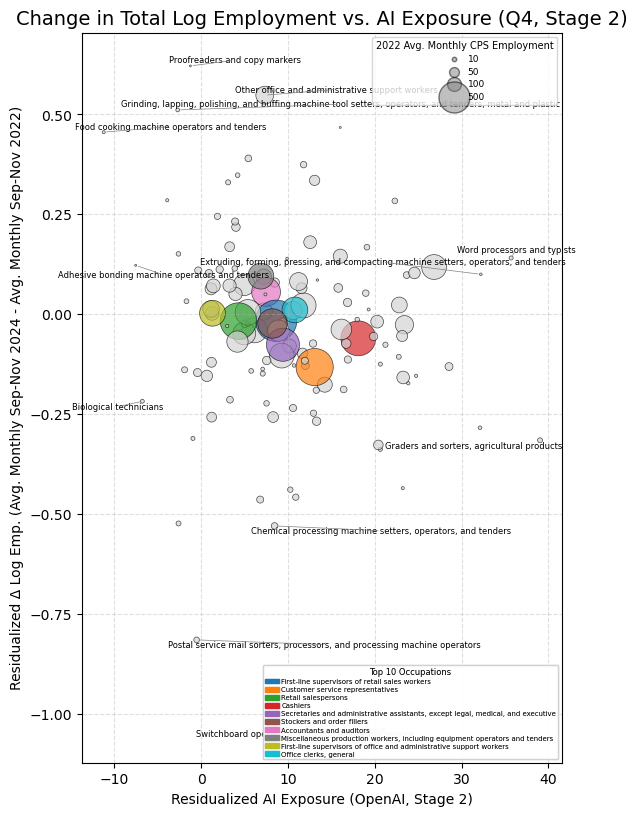

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
import matplotlib.patches as mpatches
import pandas as pd
import textwrap
import statsmodels.api as sm
import numpy as np

# Load data
df = pd.read_stata("Data/Cleaned/6M_residuals_for_plots.dta")

# Clean and prep
plot_df = df[['cps_code', 'cps_title', 'openai2_resid', 'd_log_emp_resid', 'avg_monthly_emp','DQ4_openai2']].dropna()
plot_df['cps_code'] = plot_df['cps_code'].astype(str)
plot_df = plot_df[plot_df['DQ4_openai2'] == 1].copy()

# Top 10 occupations
top_cps_codes = ['4700', '5240', '4760', '4720', '5740', '9645', '800', '8990', '5000', '5860']
palette = sns.color_palette("tab10", len(top_cps_codes))
color_map = dict(zip(top_cps_codes, palette))

# Assign colors
plot_df['color'] = plot_df['cps_code'].apply(lambda x: color_map[x] if x in top_cps_codes else 'lightgray')

# Define edge outliers using axis extremes
edge_df = pd.concat([
    plot_df.nsmallest(3, 'openai2_resid'),
    plot_df.nlargest(3, 'openai2_resid'),
    plot_df.nsmallest(3, 'd_log_emp_resid'),
    plot_df.nlargest(3, 'd_log_emp_resid')
]).drop_duplicates()

# Label only those outliers
plot_df['edge_label'] = plot_df.apply(
    lambda row: row['cps_title'] if row['cps_title'] in edge_df['cps_title'].values else None,
    axis=1
)

# Create plot
fig, ax = plt.subplots(figsize=(8, 10))

# Bubble scatter
ax.scatter(
    plot_df['openai2_resid'],
    plot_df['d_log_emp_resid'],
    s=plot_df['avg_monthly_emp'],
    color=plot_df['color'],
    alpha=0.7,
    edgecolors='black',
    linewidths=0.5
)

# --- Bubble Size Legend (top right) ---
bubble_legend = [
    plt.scatter([], [], s=size, c='gray', alpha=0.5, edgecolors='k', label=f'{size:,}')
    for size in [10, 50, 100, 500]
]

bubble_legend_obj = ax.legend(
    handles=bubble_legend,
    title='2022 Avg. Monthly CPS Employment',
    loc='upper right',
    fontsize=6.5,
    title_fontsize=7,
    frameon=True,
    labelspacing=0.4,
    handletextpad=0.5,
    borderpad=0.4
)

# --- Occupation Color Legend (bottom right) ---
patches = [
    mpatches.Patch(color=color_map[code], label=plot_df[plot_df['cps_code'] == code]['cps_title'].iloc[0])
    for code in top_cps_codes
]

occupation_legend_obj = ax.legend(
    handles=patches,
    title='Top 10 Occupations',
    loc='lower right',
    fontsize=5,
    title_fontsize=6,
    frameon=True,
    labelspacing=0.3,
    handletextpad=0.4,
    borderpad=0.3,
    ncol=1
)

# Add both legends to plot
ax.add_artist(bubble_legend_obj)
ax.add_artist(occupation_legend_obj)


from adjustText import adjust_text

texts = []

# Create label texts directly *at the point* — let adjustText do all movement
for _, row in plot_df[plot_df['edge_label'].notnull()].iterrows():
    texts.append(
        ax.text(
            row['openai2_resid'],
            row['d_log_emp_resid'],
            row['edge_label'],
            fontsize=6,
            ha='center',
            va='center'
        )
    )

# Adjust placement with proper arrows
adjust_text(
    texts,
    x=plot_df.loc[plot_df['edge_label'].notnull(), 'openai2_resid'],
    y=plot_df.loc[plot_df['edge_label'].notnull(), 'd_log_emp_resid'],
    arrowprops=dict(
        arrowstyle='-', 
        color='gray', 
        lw=0.5,
        shrinkA=2,  # shrink arrowhead from text
        shrinkB=2   # shrink arrowhead from point
    ),
    expand_text=(1.2, 1.4),
    expand_points=(1.2, 1.4),
    ax=ax
)


# Final polish
ax.set_title("Change in Total Log Employment vs. AI Exposure (Q4, Stage 2)", fontsize=14)
ax.set_xlabel("Residualized AI Exposure (OpenAI, Stage 2)")
ax.set_ylabel("Residualized Δ Log Emp. (Avg. Monthly Sep-Nov 2024 - Avg. Monthly Sep-Nov 2022)")
ax.grid(True, linestyle='--', alpha=0.4)

fig.tight_layout()
fig.subplots_adjust(right=0.75, left=0.15, top=0.88, bottom=0.15)

# Save
plt.savefig("Output/April/Bubble3/Q4_EMP_6MS2_OA.png", dpi=300, bbox_inches='tight')
plt.show()


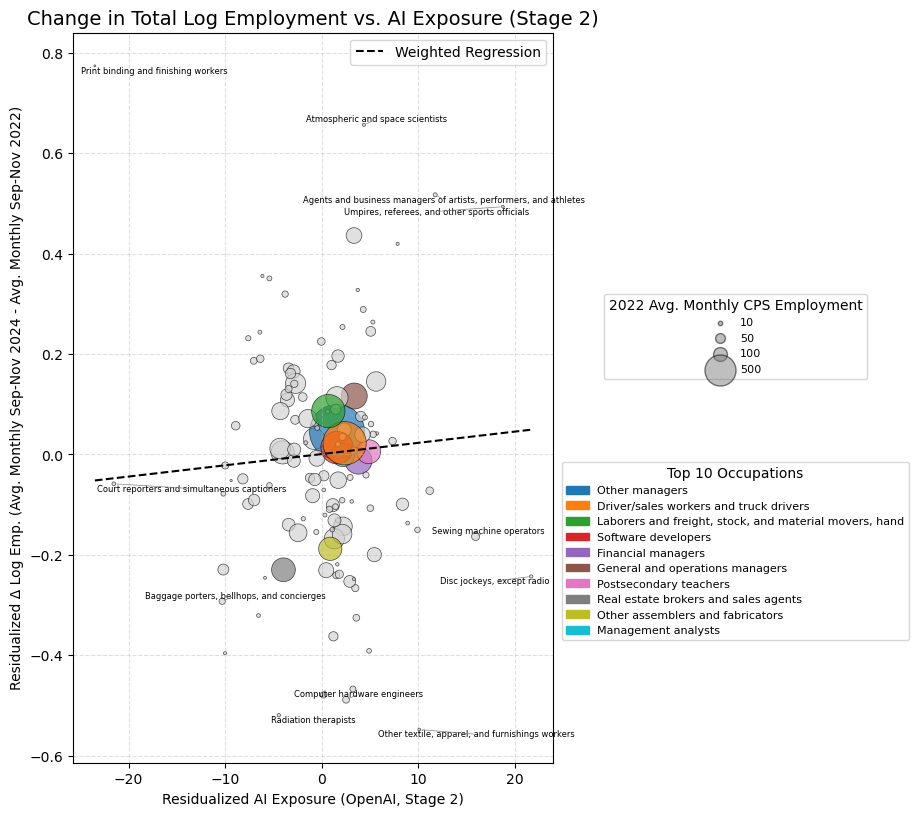

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
import matplotlib.patches as mpatches
import pandas as pd
import textwrap
import statsmodels.api as sm
import numpy as np

# Load data
df = pd.read_stata("Data/Cleaned/6M_residuals_for_plots.dta")

# Clean and prep
plot_df = df[['cps_code', 'cps_title', 'openai2_resid', 'd_log_emp_resid', 'avg_monthly_emp','DQ3_openai2']].dropna()
plot_df['cps_code'] = plot_df['cps_code'].astype(str)
plot_df = plot_df[plot_df['DQ3_openai2'] == 1].copy()

# Top 10 occupations
top_cps_codes = ['440', '9130', '9620', '1021', '120', '20', '2205', '4920', '7750', '710']
palette = sns.color_palette("tab10", len(top_cps_codes))
color_map = dict(zip(top_cps_codes, palette))

# Assign colors
plot_df['color'] = plot_df['cps_code'].apply(lambda x: color_map[x] if x in top_cps_codes else 'lightgray')

# Define edge outliers using axis extremes
edge_df = pd.concat([
    plot_df.nsmallest(3, 'openai2_resid'),
    plot_df.nlargest(3, 'openai2_resid'),
    plot_df.nsmallest(3, 'd_log_emp_resid'),
    plot_df.nlargest(3, 'd_log_emp_resid')
]).drop_duplicates()

# Label only those outliers
plot_df['edge_label'] = plot_df.apply(
    lambda row: row['cps_title'] if row['cps_title'] in edge_df['cps_title'].values else None,
    axis=1
)

# Create plot
fig, ax = plt.subplots(figsize=(8, 10))

# Bubble scatter
ax.scatter(
    plot_df['openai2_resid'],
    plot_df['d_log_emp_resid'],
    s=plot_df['avg_monthly_emp'],
    color=plot_df['color'],
    alpha=0.7,
    edgecolors='black',
    linewidths=0.5
)

# Drop NA rows used for regression
dfw = plot_df.dropna(subset=['openai2_resid', 'd_log_emp_resid', 'avg_monthly_emp'])

# Define X, y, and weights
X = sm.add_constant(dfw['openai2_resid'])
y = dfw['d_log_emp_resid']
weights = dfw['avg_monthly_emp']

# Fit weighted least squares model
wls_model = sm.WLS(y, X, weights=weights)
results = wls_model.fit()

# Predict values for plotting the regression line
x_vals = np.linspace(dfw['openai2_resid'].min(), dfw['openai2_resid'].max(), 100)
X_pred = sm.add_constant(x_vals)
y_pred = results.predict(X_pred)

# Plot weighted regression line
ax.plot(x_vals, y_pred, color='black', linestyle='--', linewidth=1.5, label='Weighted Regression')
ax.legend()

# Legends
patches = [
    mpatches.Patch(color=color_map[code], label=plot_df[plot_df['cps_code'] == code]['cps_title'].iloc[0])
    for code in top_cps_codes
]
bubble_legend = [
    plt.scatter([], [], s=size, c='gray', alpha=0.5, edgecolors='k', label=f'{size:,}')
    for size in [10, 50, 100, 500]
]

legend_center_x = 1.38
bubble_legend_y = 0.65
top10_legend_y = 0.42

fig.legend(
    handles=bubble_legend,
    title='2022 Avg. Monthly CPS Employment',
    loc='upper center',
    bbox_to_anchor=(legend_center_x, bubble_legend_y),
    bbox_transform=ax.transAxes,
    fontsize=8,
    frameon=True
)

fig.legend(
    handles=patches,
    title='Top 10 Occupations',
    loc='upper center',
    bbox_to_anchor=(legend_center_x, top10_legend_y),
    bbox_transform=ax.transAxes,
    ncol=1,
    fontsize=8,
    frameon=True
)

from adjustText import adjust_text

texts = []

# Create label texts directly *at the point* — let adjustText do all movement
for _, row in plot_df[plot_df['edge_label'].notnull()].iterrows():
    texts.append(
        ax.text(
            row['openai2_resid'],
            row['d_log_emp_resid'],
            row['edge_label'],
            fontsize=6,
            ha='center',
            va='center'
        )
    )

# Adjust placement with proper arrows
adjust_text(
    texts,
    x=plot_df.loc[plot_df['edge_label'].notnull(), 'openai2_resid'],
    y=plot_df.loc[plot_df['edge_label'].notnull(), 'd_log_emp_resid'],
    arrowprops=dict(
        arrowstyle='-', 
        color='gray', 
        lw=0.5,
        shrinkA=2,  # shrink arrowhead from text
        shrinkB=2   # shrink arrowhead from point
    ),
    expand_text=(1.2, 1.4),
    expand_points=(1.2, 1.4),
    ax=ax
)


# Final polish
ax.set_title("Change in Total Log Employment vs. AI Exposure (Stage 2)", fontsize=14)
ax.set_xlabel("Residualized AI Exposure (OpenAI, Stage 2)")
ax.set_ylabel("Residualized Δ Log Emp. (Avg. Monthly Sep-Nov 2024 - Avg. Monthly Sep-Nov 2022)")
ax.grid(True, linestyle='--', alpha=0.4)

fig.tight_layout()
fig.subplots_adjust(right=0.75, left=0.15, top=0.88, bottom=0.15)

# Save
plt.savefig("Output/April/Bubble3/Q3_EMP_6MS2_OA.png", dpi=300, bbox_inches='tight')
plt.show()


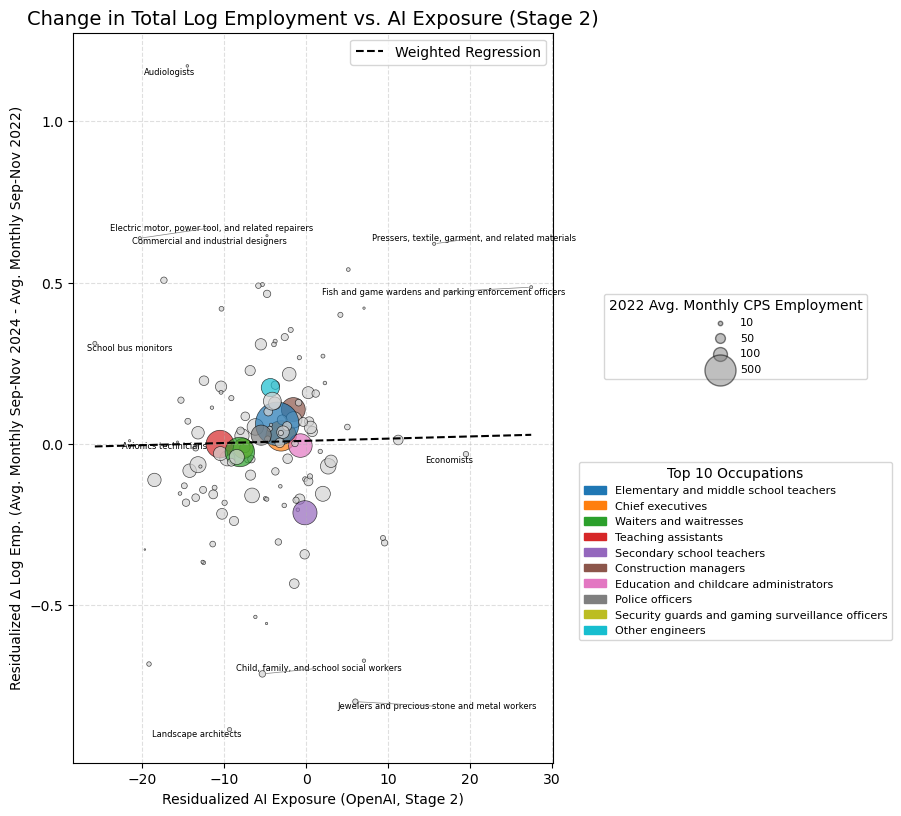

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
import matplotlib.patches as mpatches
import pandas as pd
import textwrap
import statsmodels.api as sm
import numpy as np

# Load data
df = pd.read_stata("Data/Cleaned/6M_residuals_for_plots.dta")

# Clean and prep
plot_df = df[['cps_code', 'cps_title', 'openai2_resid', 'd_log_emp_resid', 'avg_monthly_emp','DQ2_openai2']].dropna()
plot_df['cps_code'] = plot_df['cps_code'].astype(str)
plot_df = plot_df[plot_df['DQ2_openai2'] == 1].copy()

# Top 10 occupations
top_cps_codes = ['2310', '10', '4110', '2545', '2320', '220', '230', '3870', '3930', '1530']
palette = sns.color_palette("tab10", len(top_cps_codes))
color_map = dict(zip(top_cps_codes, palette))

# Assign colors
plot_df['color'] = plot_df['cps_code'].apply(lambda x: color_map[x] if x in top_cps_codes else 'lightgray')

# Define edge outliers using axis extremes
edge_df = pd.concat([
    plot_df.nsmallest(3, 'openai2_resid'),
    plot_df.nlargest(3, 'openai2_resid'),
    plot_df.nsmallest(3, 'd_log_emp_resid'),
    plot_df.nlargest(3, 'd_log_emp_resid')
]).drop_duplicates()

# Label only those outliers
plot_df['edge_label'] = plot_df.apply(
    lambda row: row['cps_title'] if row['cps_title'] in edge_df['cps_title'].values else None,
    axis=1
)

# Create plot
fig, ax = plt.subplots(figsize=(8, 10))

# Bubble scatter
ax.scatter(
    plot_df['openai2_resid'],
    plot_df['d_log_emp_resid'],
    s=plot_df['avg_monthly_emp'],
    color=plot_df['color'],
    alpha=0.7,
    edgecolors='black',
    linewidths=0.5
)

# Drop NA rows used for regression
dfw = plot_df.dropna(subset=['openai2_resid', 'd_log_emp_resid', 'avg_monthly_emp'])

# Define X, y, and weights
X = sm.add_constant(dfw['openai2_resid'])
y = dfw['d_log_emp_resid']
weights = dfw['avg_monthly_emp']

# Fit weighted least squares model
wls_model = sm.WLS(y, X, weights=weights)
results = wls_model.fit()

# Predict values for plotting the regression line
x_vals = np.linspace(dfw['openai2_resid'].min(), dfw['openai2_resid'].max(), 100)
X_pred = sm.add_constant(x_vals)
y_pred = results.predict(X_pred)

# Plot weighted regression line
ax.plot(x_vals, y_pred, color='black', linestyle='--', linewidth=1.5, label='Weighted Regression')
ax.legend()

# Legends
patches = [
    mpatches.Patch(color=color_map[code], label=plot_df[plot_df['cps_code'] == code]['cps_title'].iloc[0])
    for code in top_cps_codes
]
bubble_legend = [
    plt.scatter([], [], s=size, c='gray', alpha=0.5, edgecolors='k', label=f'{size:,}')
    for size in [10, 50, 100, 500]
]

legend_center_x = 1.38
bubble_legend_y = 0.65
top10_legend_y = 0.42

fig.legend(
    handles=bubble_legend,
    title='2022 Avg. Monthly CPS Employment',
    loc='upper center',
    bbox_to_anchor=(legend_center_x, bubble_legend_y),
    bbox_transform=ax.transAxes,
    fontsize=8,
    frameon=True
)

fig.legend(
    handles=patches,
    title='Top 10 Occupations',
    loc='upper center',
    bbox_to_anchor=(legend_center_x, top10_legend_y),
    bbox_transform=ax.transAxes,
    ncol=1,
    fontsize=8,
    frameon=True
)

from adjustText import adjust_text

texts = []

# Create label texts directly *at the point* — let adjustText do all movement
for _, row in plot_df[plot_df['edge_label'].notnull()].iterrows():
    texts.append(
        ax.text(
            row['openai2_resid'],
            row['d_log_emp_resid'],
            row['edge_label'],
            fontsize=6,
            ha='center',
            va='center'
        )
    )

# Adjust placement with proper arrows
adjust_text(
    texts,
    x=plot_df.loc[plot_df['edge_label'].notnull(), 'openai2_resid'],
    y=plot_df.loc[plot_df['edge_label'].notnull(), 'd_log_emp_resid'],
    arrowprops=dict(
        arrowstyle='-', 
        color='gray', 
        lw=0.5,
        shrinkA=2,  # shrink arrowhead from text
        shrinkB=2   # shrink arrowhead from point
    ),
    expand_text=(1.2, 1.4),
    expand_points=(1.2, 1.4),
    ax=ax
)


# Final polish
ax.set_title("Change in Total Log Employment vs. AI Exposure (Stage 2)", fontsize=14)
ax.set_xlabel("Residualized AI Exposure (OpenAI, Stage 2)")
ax.set_ylabel("Residualized Δ Log Emp. (Avg. Monthly Sep-Nov 2024 - Avg. Monthly Sep-Nov 2022)")
ax.grid(True, linestyle='--', alpha=0.4)

fig.tight_layout()
fig.subplots_adjust(right=0.75, left=0.15, top=0.88, bottom=0.15)

# Save
plt.savefig("Output/April/Bubble3/Q2_EMP_6MS2_OA.png", dpi=300, bbox_inches='tight')
plt.show()


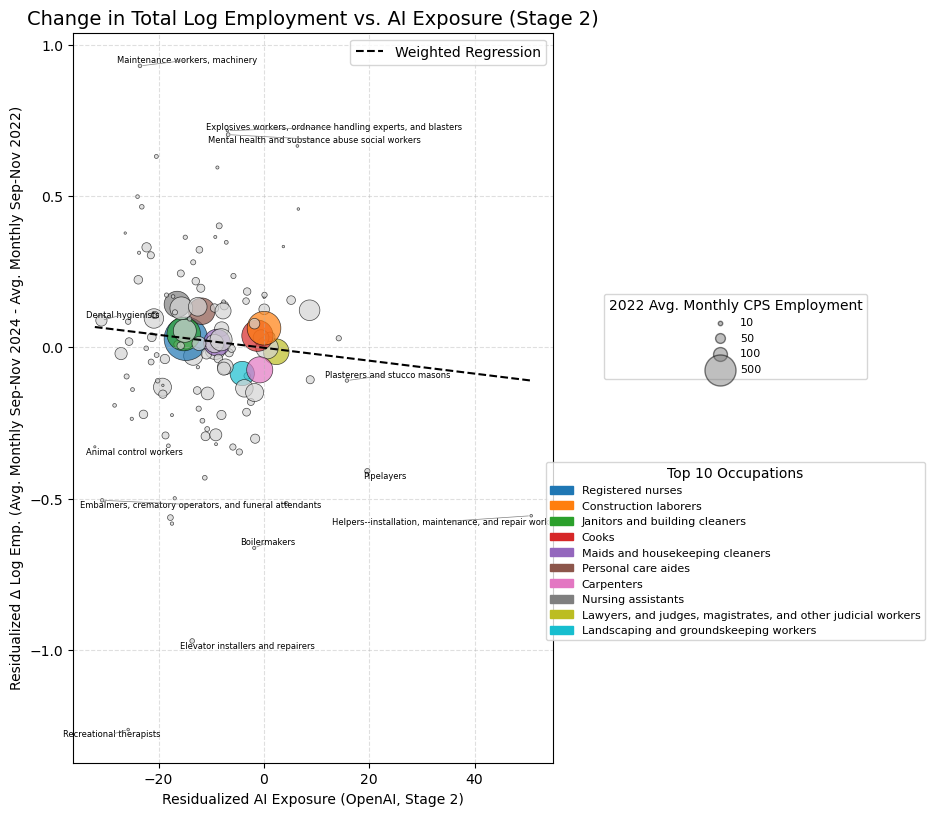

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
import matplotlib.patches as mpatches
import pandas as pd
import textwrap
import statsmodels.api as sm
import numpy as np

# Load data
df = pd.read_stata("Data/Cleaned/6M_residuals_for_plots.dta")

# Clean and prep
plot_df = df[['cps_code', 'cps_title', 'openai2_resid', 'd_log_emp_resid', 'avg_monthly_emp','DQ1_openai2']].dropna()
plot_df['cps_code'] = plot_df['cps_code'].astype(str)
plot_df = plot_df[plot_df['DQ1_openai2'] == 1].copy()

# Top 10 occupations
top_cps_codes = ['3255', '6260', '4220', '4020', '4230', '3602', '6230', '3603', '2100', '4251']
palette = sns.color_palette("tab10", len(top_cps_codes))
color_map = dict(zip(top_cps_codes, palette))

# Assign colors
plot_df['color'] = plot_df['cps_code'].apply(lambda x: color_map[x] if x in top_cps_codes else 'lightgray')

# Define edge outliers using axis extremes
edge_df = pd.concat([
    plot_df.nsmallest(3, 'openai2_resid'),
    plot_df.nlargest(3, 'openai2_resid'),
    plot_df.nsmallest(3, 'd_log_emp_resid'),
    plot_df.nlargest(3, 'd_log_emp_resid')
]).drop_duplicates()

# Label only those outliers
plot_df['edge_label'] = plot_df.apply(
    lambda row: row['cps_title'] if row['cps_title'] in edge_df['cps_title'].values else None,
    axis=1
)

# Create plot
fig, ax = plt.subplots(figsize=(8, 10))

# Bubble scatter
ax.scatter(
    plot_df['openai2_resid'],
    plot_df['d_log_emp_resid'],
    s=plot_df['avg_monthly_emp'],
    color=plot_df['color'],
    alpha=0.7,
    edgecolors='black',
    linewidths=0.5
)

# Drop NA rows used for regression
dfw = plot_df.dropna(subset=['openai2_resid', 'd_log_emp_resid', 'avg_monthly_emp'])

# Define X, y, and weights
X = sm.add_constant(dfw['openai2_resid'])
y = dfw['d_log_emp_resid']
weights = dfw['avg_monthly_emp']

# Fit weighted least squares model
wls_model = sm.WLS(y, X, weights=weights)
results = wls_model.fit()

# Predict values for plotting the regression line
x_vals = np.linspace(dfw['openai2_resid'].min(), dfw['openai2_resid'].max(), 100)
X_pred = sm.add_constant(x_vals)
y_pred = results.predict(X_pred)

# Plot weighted regression line
ax.plot(x_vals, y_pred, color='black', linestyle='--', linewidth=1.5, label='Weighted Regression')
ax.legend()

# Legends
patches = [
    mpatches.Patch(color=color_map[code], label=plot_df[plot_df['cps_code'] == code]['cps_title'].iloc[0])
    for code in top_cps_codes
]
bubble_legend = [
    plt.scatter([], [], s=size, c='gray', alpha=0.5, edgecolors='k', label=f'{size:,}')
    for size in [10, 50, 100, 500]
]

legend_center_x = 1.38
bubble_legend_y = 0.65
top10_legend_y = 0.42

fig.legend(
    handles=bubble_legend,
    title='2022 Avg. Monthly CPS Employment',
    loc='upper center',
    bbox_to_anchor=(legend_center_x, bubble_legend_y),
    bbox_transform=ax.transAxes,
    fontsize=8,
    frameon=True
)

fig.legend(
    handles=patches,
    title='Top 10 Occupations',
    loc='upper center',
    bbox_to_anchor=(legend_center_x, top10_legend_y),
    bbox_transform=ax.transAxes,
    ncol=1,
    fontsize=8,
    frameon=True
)

from adjustText import adjust_text

texts = []

# Create label texts directly *at the point* — let adjustText do all movement
for _, row in plot_df[plot_df['edge_label'].notnull()].iterrows():
    texts.append(
        ax.text(
            row['openai2_resid'],
            row['d_log_emp_resid'],
            row['edge_label'],
            fontsize=6,
            ha='center',
            va='center'
        )
    )

# Adjust placement with proper arrows
adjust_text(
    texts,
    x=plot_df.loc[plot_df['edge_label'].notnull(), 'openai2_resid'],
    y=plot_df.loc[plot_df['edge_label'].notnull(), 'd_log_emp_resid'],
    arrowprops=dict(
        arrowstyle='-', 
        color='gray', 
        lw=0.5,
        shrinkA=2,  # shrink arrowhead from text
        shrinkB=2   # shrink arrowhead from point
    ),
    expand_text=(1.2, 1.4),
    expand_points=(1.2, 1.4),
    ax=ax
)


# Final polish
ax.set_title("Change in Total Log Employment vs. AI Exposure (Stage 2)", fontsize=14)
ax.set_xlabel("Residualized AI Exposure (OpenAI, Stage 2)")
ax.set_ylabel("Residualized Δ Log Emp. (Avg. Monthly Sep-Nov 2024 - Avg. Monthly Sep-Nov 2022)")
ax.grid(True, linestyle='--', alpha=0.4)

fig.tight_layout()
fig.subplots_adjust(right=0.75, left=0.15, top=0.88, bottom=0.15)

# Save
plt.savefig("Output/April/Bubble3/Q1_EMP_6MS2_OA.png", dpi=300, bbox_inches='tight')
plt.show()


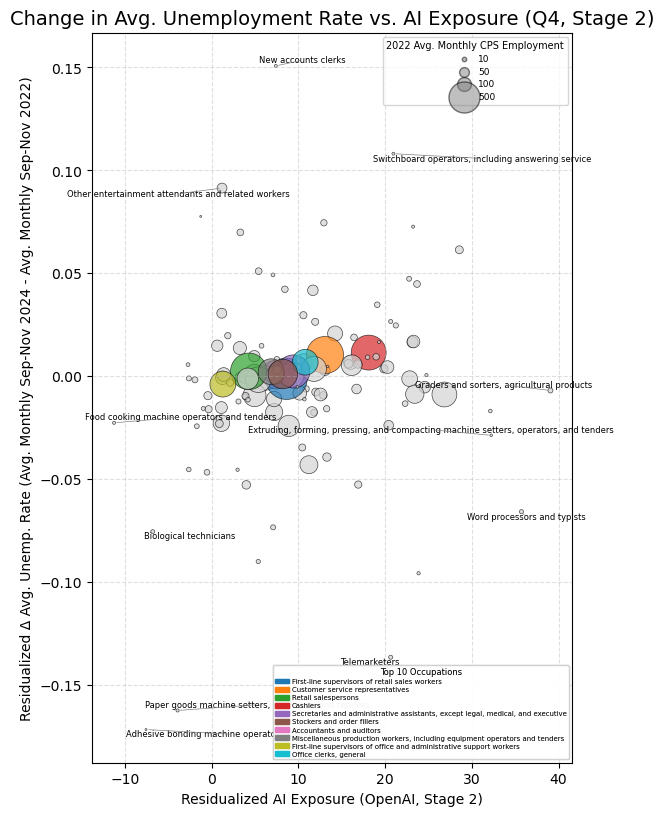

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
import matplotlib.patches as mpatches
import pandas as pd
import textwrap
import statsmodels.api as sm
import numpy as np

# Load data
df = pd.read_stata("Data/Cleaned/6M_residuals_for_plots.dta")

# Clean and prep
plot_df = df[['cps_code', 'cps_title', 'openai2_resid', 'd_unemp_rate_resid', 'avg_monthly_emp','DQ4_openai2']].dropna()
plot_df['cps_code'] = plot_df['cps_code'].astype(str)
plot_df = plot_df[plot_df['DQ4_openai2'] == 1].copy()

# Top 10 occupations
top_cps_codes = ['4700', '5240', '4760', '4720', '5740', '9645', '800', '8990', '5000', '5860']
palette = sns.color_palette("tab10", len(top_cps_codes))
color_map = dict(zip(top_cps_codes, palette))

# Assign colors
plot_df['color'] = plot_df['cps_code'].apply(lambda x: color_map[x] if x in top_cps_codes else 'lightgray')

# Define edge outliers using axis extremes
edge_df = pd.concat([
    plot_df.nsmallest(3, 'openai2_resid'),
    plot_df.nlargest(3, 'openai2_resid'),
    plot_df.nsmallest(3, 'd_unemp_rate_resid'),
    plot_df.nlargest(3, 'd_unemp_rate_resid')
]).drop_duplicates()

# Label only those outliers
plot_df['edge_label'] = plot_df.apply(
    lambda row: row['cps_title'] if row['cps_title'] in edge_df['cps_title'].values else None,
    axis=1
)

# Create plot
fig, ax = plt.subplots(figsize=(8, 10))

# Bubble scatter
ax.scatter(
    plot_df['openai2_resid'],
    plot_df['d_unemp_rate_resid'],
    s=plot_df['avg_monthly_emp'],
    color=plot_df['color'],
    alpha=0.7,
    edgecolors='black',
    linewidths=0.5
)

# --- Bubble Size Legend (top right) ---
bubble_legend = [
    plt.scatter([], [], s=size, c='gray', alpha=0.5, edgecolors='k', label=f'{size:,}')
    for size in [10, 50, 100, 500]
]

bubble_legend_obj = ax.legend(
    handles=bubble_legend,
    title='2022 Avg. Monthly CPS Employment',
    loc='upper right',
    fontsize=6.5,
    title_fontsize=7,
    frameon=True,
    labelspacing=0.4,
    handletextpad=0.5,
    borderpad=0.4
)

# --- Occupation Color Legend (bottom right) ---
patches = [
    mpatches.Patch(color=color_map[code], label=plot_df[plot_df['cps_code'] == code]['cps_title'].iloc[0])
    for code in top_cps_codes
]

occupation_legend_obj = ax.legend(
    handles=patches,
    title='Top 10 Occupations',
    loc='lower right',
    fontsize=5,
    title_fontsize=6,
    frameon=True,
    labelspacing=0.3,
    handletextpad=0.4,
    borderpad=0.3,
    ncol=1
)

# Add both legends to plot
ax.add_artist(bubble_legend_obj)
ax.add_artist(occupation_legend_obj)


from adjustText import adjust_text

texts = []

# Create label texts directly *at the point* — let adjustText do all movement
for _, row in plot_df[plot_df['edge_label'].notnull()].iterrows():
    texts.append(
        ax.text(
            row['openai2_resid'],
            row['d_unemp_rate_resid'],
            row['edge_label'],
            fontsize=6,
            ha='center',
            va='center'
        )
    )

# Adjust placement with proper arrows
adjust_text(
    texts,
    x=plot_df.loc[plot_df['edge_label'].notnull(), 'openai2_resid'],
    y=plot_df.loc[plot_df['edge_label'].notnull(), 'd_unemp_rate_resid'],
    arrowprops=dict(
        arrowstyle='-', 
        color='gray', 
        lw=0.5,
        shrinkA=2,  # shrink arrowhead from text
        shrinkB=2   # shrink arrowhead from point
    ),
    expand_text=(1.2, 1.4),
    expand_points=(1.2, 1.4),
    ax=ax
)


# Final polish
ax.set_title("Change in Avg. Unemployment Rate vs. AI Exposure (Q4, Stage 2)", fontsize=14)
ax.set_xlabel("Residualized AI Exposure (OpenAI, Stage 2)")
ax.set_ylabel("Residualized Δ Avg. Unemp. Rate (Avg. Monthly Sep-Nov 2024 - Avg. Monthly Sep-Nov 2022)")
ax.grid(True, linestyle='--', alpha=0.4)

fig.tight_layout()
fig.subplots_adjust(right=0.75, left=0.15, top=0.88, bottom=0.15)

# Save
plt.savefig("Output/April/Bubble3/Q4_UNEMP_6MS2_OA.png", dpi=300, bbox_inches='tight')
plt.show()


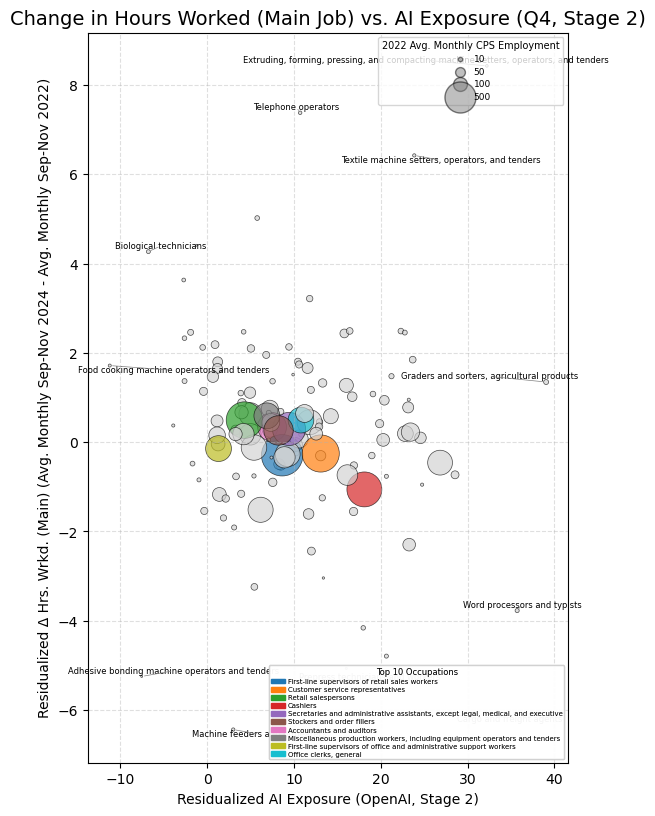

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
import matplotlib.patches as mpatches
import pandas as pd
import textwrap
import statsmodels.api as sm
import numpy as np

# Load data
df = pd.read_stata("Data/Cleaned/6M_residuals_for_plots.dta")

# Clean and prep
plot_df = df[['cps_code', 'cps_title', 'openai2_resid', 'd_ahrswork1_resid', 'avg_monthly_emp','DQ4_openai2']].dropna()
plot_df['cps_code'] = plot_df['cps_code'].astype(str)
plot_df = plot_df[plot_df['DQ4_openai2'] == 1].copy()

# Top 10 occupations
top_cps_codes = ['4700', '5240', '4760', '4720', '5740', '9645', '800', '8990', '5000', '5860']
palette = sns.color_palette("tab10", len(top_cps_codes))
color_map = dict(zip(top_cps_codes, palette))

# Assign colors
plot_df['color'] = plot_df['cps_code'].apply(lambda x: color_map[x] if x in top_cps_codes else 'lightgray')

# Define edge outliers using axis extremes
edge_df = pd.concat([
    plot_df.nsmallest(3, 'openai2_resid'),
    plot_df.nlargest(3, 'openai2_resid'),
    plot_df.nsmallest(3, 'd_ahrswork1_resid'),
    plot_df.nlargest(3, 'd_ahrswork1_resid')
]).drop_duplicates()

# Label only those outliers
plot_df['edge_label'] = plot_df.apply(
    lambda row: row['cps_title'] if row['cps_title'] in edge_df['cps_title'].values else None,
    axis=1
)

# Create plot
fig, ax = plt.subplots(figsize=(8, 10))

# Bubble scatter
ax.scatter(
    plot_df['openai2_resid'],
    plot_df['d_ahrswork1_resid'],
    s=plot_df['avg_monthly_emp'],
    color=plot_df['color'],
    alpha=0.7,
    edgecolors='black',
    linewidths=0.5
)

# --- Bubble Size Legend (top right) ---
bubble_legend = [
    plt.scatter([], [], s=size, c='gray', alpha=0.5, edgecolors='k', label=f'{size:,}')
    for size in [10, 50, 100, 500]
]

bubble_legend_obj = ax.legend(
    handles=bubble_legend,
    title='2022 Avg. Monthly CPS Employment',
    loc='upper right',
    fontsize=6.5,
    title_fontsize=7,
    frameon=True,
    labelspacing=0.4,
    handletextpad=0.5,
    borderpad=0.4
)

# --- Occupation Color Legend (bottom right) ---
patches = [
    mpatches.Patch(color=color_map[code], label=plot_df[plot_df['cps_code'] == code]['cps_title'].iloc[0])
    for code in top_cps_codes
]

occupation_legend_obj = ax.legend(
    handles=patches,
    title='Top 10 Occupations',
    loc='lower right',
    fontsize=5,
    title_fontsize=6,
    frameon=True,
    labelspacing=0.3,
    handletextpad=0.4,
    borderpad=0.3,
    ncol=1
)

# Add both legends to plot
ax.add_artist(bubble_legend_obj)
ax.add_artist(occupation_legend_obj)


from adjustText import adjust_text

texts = []

# Create label texts directly *at the point* — let adjustText do all movement
for _, row in plot_df[plot_df['edge_label'].notnull()].iterrows():
    texts.append(
        ax.text(
            row['openai2_resid'],
            row['d_ahrswork1_resid'],
            row['edge_label'],
            fontsize=6,
            ha='center',
            va='center'
        )
    )

# Adjust placement with proper arrows
adjust_text(
    texts,
    x=plot_df.loc[plot_df['edge_label'].notnull(), 'openai2_resid'],
    y=plot_df.loc[plot_df['edge_label'].notnull(), 'd_ahrswork1_resid'],
    arrowprops=dict(
        arrowstyle='-', 
        color='gray', 
        lw=0.5,
        shrinkA=2,  # shrink arrowhead from text
        shrinkB=2   # shrink arrowhead from point
    ),
    expand_text=(1.2, 1.4),
    expand_points=(1.2, 1.4),
    ax=ax
)


# Final polish
ax.set_title("Change in Hours Worked (Main Job) vs. AI Exposure (Q4, Stage 2)", fontsize=14)
ax.set_xlabel("Residualized AI Exposure (OpenAI, Stage 2)")
ax.set_ylabel("Residualized Δ Hrs. Wrkd. (Main) (Avg. Monthly Sep-Nov 2024 - Avg. Monthly Sep-Nov 2022)")
ax.grid(True, linestyle='--', alpha=0.4)

fig.tight_layout()
fig.subplots_adjust(right=0.75, left=0.15, top=0.88, bottom=0.15)

# Save
plt.savefig("Output/April/Bubble3/Q4_AH1_6MS2_OA.png", dpi=300, bbox_inches='tight')
plt.show()


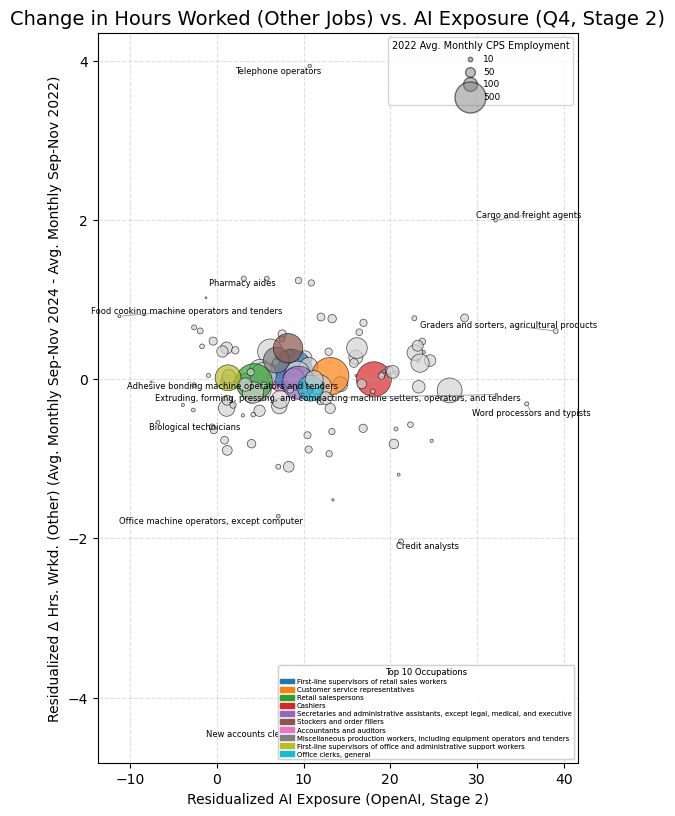

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
import matplotlib.patches as mpatches
import pandas as pd
import textwrap
import statsmodels.api as sm
import numpy as np

# Load data
df = pd.read_stata("Data/Cleaned/6M_residuals_for_plots.dta")

# Clean and prep
plot_df = df[['cps_code', 'cps_title', 'openai2_resid', 'd_ahrswork2_resid', 'avg_monthly_emp','DQ4_openai2']].dropna()
plot_df['cps_code'] = plot_df['cps_code'].astype(str)
plot_df = plot_df[plot_df['DQ4_openai2'] == 1].copy()

# Top 10 occupations
top_cps_codes = ['4700', '5240', '4760', '4720', '5740', '9645', '800', '8990', '5000', '5860']
palette = sns.color_palette("tab10", len(top_cps_codes))
color_map = dict(zip(top_cps_codes, palette))

# Assign colors
plot_df['color'] = plot_df['cps_code'].apply(lambda x: color_map[x] if x in top_cps_codes else 'lightgray')

# Define edge outliers using axis extremes
edge_df = pd.concat([
    plot_df.nsmallest(3, 'openai2_resid'),
    plot_df.nlargest(3, 'openai2_resid'),
    plot_df.nsmallest(3, 'd_ahrswork2_resid'),
    plot_df.nlargest(3, 'd_ahrswork2_resid')
]).drop_duplicates()

# Label only those outliers
plot_df['edge_label'] = plot_df.apply(
    lambda row: row['cps_title'] if row['cps_title'] in edge_df['cps_title'].values else None,
    axis=1
)

# Create plot
fig, ax = plt.subplots(figsize=(8, 10))

# Bubble scatter
ax.scatter(
    plot_df['openai2_resid'],
    plot_df['d_ahrswork2_resid'],
    s=plot_df['avg_monthly_emp'],
    color=plot_df['color'],
    alpha=0.7,
    edgecolors='black',
    linewidths=0.5
)

# --- Bubble Size Legend (top right) ---
bubble_legend = [
    plt.scatter([], [], s=size, c='gray', alpha=0.5, edgecolors='k', label=f'{size:,}')
    for size in [10, 50, 100, 500]
]

bubble_legend_obj = ax.legend(
    handles=bubble_legend,
    title='2022 Avg. Monthly CPS Employment',
    loc='upper right',
    fontsize=6.5,
    title_fontsize=7,
    frameon=True,
    labelspacing=0.4,
    handletextpad=0.5,
    borderpad=0.4
)

# --- Occupation Color Legend (bottom right) ---
patches = [
    mpatches.Patch(color=color_map[code], label=plot_df[plot_df['cps_code'] == code]['cps_title'].iloc[0])
    for code in top_cps_codes
]

occupation_legend_obj = ax.legend(
    handles=patches,
    title='Top 10 Occupations',
    loc='lower right',
    fontsize=5,
    title_fontsize=6,
    frameon=True,
    labelspacing=0.3,
    handletextpad=0.4,
    borderpad=0.3,
    ncol=1
)

# Add both legends to plot
ax.add_artist(bubble_legend_obj)
ax.add_artist(occupation_legend_obj)


from adjustText import adjust_text

texts = []

# Create label texts directly *at the point* — let adjustText do all movement
for _, row in plot_df[plot_df['edge_label'].notnull()].iterrows():
    texts.append(
        ax.text(
            row['openai2_resid'],
            row['d_ahrswork2_resid'],
            row['edge_label'],
            fontsize=6,
            ha='center',
            va='center'
        )
    )

# Adjust placement with proper arrows
adjust_text(
    texts,
    x=plot_df.loc[plot_df['edge_label'].notnull(), 'openai2_resid'],
    y=plot_df.loc[plot_df['edge_label'].notnull(), 'd_ahrswork2_resid'],
    arrowprops=dict(
        arrowstyle='-', 
        color='gray', 
        lw=0.5,
        shrinkA=2,  # shrink arrowhead from text
        shrinkB=2   # shrink arrowhead from point
    ),
    expand_text=(1.2, 1.4),
    expand_points=(1.2, 1.4),
    ax=ax
)


# Final polish
ax.set_title("Change in Hours Worked (Other Jobs) vs. AI Exposure (Q4, Stage 2)", fontsize=14)
ax.set_xlabel("Residualized AI Exposure (OpenAI, Stage 2)")
ax.set_ylabel("Residualized Δ Hrs. Wrkd. (Other) (Avg. Monthly Sep-Nov 2024 - Avg. Monthly Sep-Nov 2022)")
ax.grid(True, linestyle='--', alpha=0.4)

fig.tight_layout()
fig.subplots_adjust(right=0.75, left=0.15, top=0.88, bottom=0.15)

# Save
plt.savefig("Output/April/Bubble3/Q4_AH2_6MS2_OA.png", dpi=300, bbox_inches='tight')
plt.show()


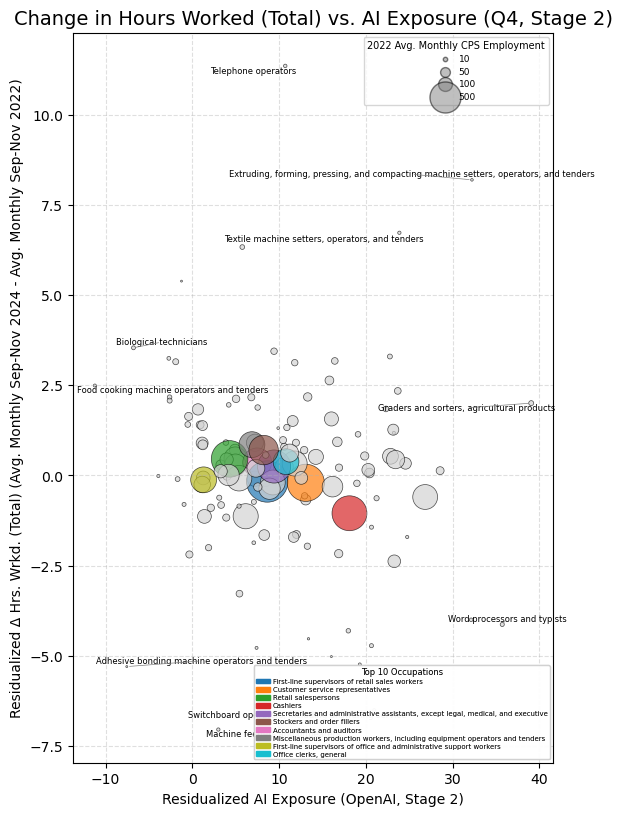

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
import matplotlib.patches as mpatches
import pandas as pd
import textwrap
import statsmodels.api as sm
import numpy as np

# Load data
df = pd.read_stata("Data/Cleaned/6M_residuals_for_plots.dta")

# Clean and prep
plot_df = df[['cps_code', 'cps_title', 'openai2_resid', 'd_ahrsworkt_resid', 'avg_monthly_emp','DQ4_openai2']].dropna()
plot_df['cps_code'] = plot_df['cps_code'].astype(str)
plot_df = plot_df[plot_df['DQ4_openai2'] == 1].copy()

# Top 10 occupations
top_cps_codes = ['4700', '5240', '4760', '4720', '5740', '9645', '800', '8990', '5000', '5860']
palette = sns.color_palette("tab10", len(top_cps_codes))
color_map = dict(zip(top_cps_codes, palette))

# Assign colors
plot_df['color'] = plot_df['cps_code'].apply(lambda x: color_map[x] if x in top_cps_codes else 'lightgray')

# Define edge outliers using axis extremes
edge_df = pd.concat([
    plot_df.nsmallest(3, 'openai2_resid'),
    plot_df.nlargest(3, 'openai2_resid'),
    plot_df.nsmallest(3, 'd_ahrsworkt_resid'),
    plot_df.nlargest(3, 'd_ahrsworkt_resid')
]).drop_duplicates()

# Label only those outliers
plot_df['edge_label'] = plot_df.apply(
    lambda row: row['cps_title'] if row['cps_title'] in edge_df['cps_title'].values else None,
    axis=1
)

# Create plot
fig, ax = plt.subplots(figsize=(8, 10))

# Bubble scatter
ax.scatter(
    plot_df['openai2_resid'],
    plot_df['d_ahrsworkt_resid'],
    s=plot_df['avg_monthly_emp'],
    color=plot_df['color'],
    alpha=0.7,
    edgecolors='black',
    linewidths=0.5
)

# --- Bubble Size Legend (top right) ---
bubble_legend = [
    plt.scatter([], [], s=size, c='gray', alpha=0.5, edgecolors='k', label=f'{size:,}')
    for size in [10, 50, 100, 500]
]

bubble_legend_obj = ax.legend(
    handles=bubble_legend,
    title='2022 Avg. Monthly CPS Employment',
    loc='upper right',
    fontsize=6.5,
    title_fontsize=7,
    frameon=True,
    labelspacing=0.4,
    handletextpad=0.5,
    borderpad=0.4
)

# --- Occupation Color Legend (bottom right) ---
patches = [
    mpatches.Patch(color=color_map[code], label=plot_df[plot_df['cps_code'] == code]['cps_title'].iloc[0])
    for code in top_cps_codes
]

occupation_legend_obj = ax.legend(
    handles=patches,
    title='Top 10 Occupations',
    loc='lower right',
    fontsize=5,
    title_fontsize=6,
    frameon=True,
    labelspacing=0.3,
    handletextpad=0.4,
    borderpad=0.3,
    ncol=1
)

# Add both legends to plot
ax.add_artist(bubble_legend_obj)
ax.add_artist(occupation_legend_obj)


from adjustText import adjust_text

texts = []

# Create label texts directly *at the point* — let adjustText do all movement
for _, row in plot_df[plot_df['edge_label'].notnull()].iterrows():
    texts.append(
        ax.text(
            row['openai2_resid'],
            row['d_ahrsworkt_resid'],
            row['edge_label'],
            fontsize=6,
            ha='center',
            va='center'
        )
    )

# Adjust placement with proper arrows
adjust_text(
    texts,
    x=plot_df.loc[plot_df['edge_label'].notnull(), 'openai2_resid'],
    y=plot_df.loc[plot_df['edge_label'].notnull(), 'd_ahrsworkt_resid'],
    arrowprops=dict(
        arrowstyle='-', 
        color='gray', 
        lw=0.5,
        shrinkA=2,  # shrink arrowhead from text
        shrinkB=2   # shrink arrowhead from point
    ),
    expand_text=(1.2, 1.4),
    expand_points=(1.2, 1.4),
    ax=ax
)


# Final polish
ax.set_title("Change in Hours Worked (Total) vs. AI Exposure (Q4, Stage 2)", fontsize=14)
ax.set_xlabel("Residualized AI Exposure (OpenAI, Stage 2)")
ax.set_ylabel("Residualized Δ Hrs. Wrkd. (Total) (Avg. Monthly Sep-Nov 2024 - Avg. Monthly Sep-Nov 2022)")
ax.grid(True, linestyle='--', alpha=0.4)

fig.tight_layout()
fig.subplots_adjust(right=0.75, left=0.15, top=0.88, bottom=0.15)

# Save
plt.savefig("Output/April/Bubble3/Q4_AHT_6MS2_OA.png", dpi=300, bbox_inches='tight')
plt.show()


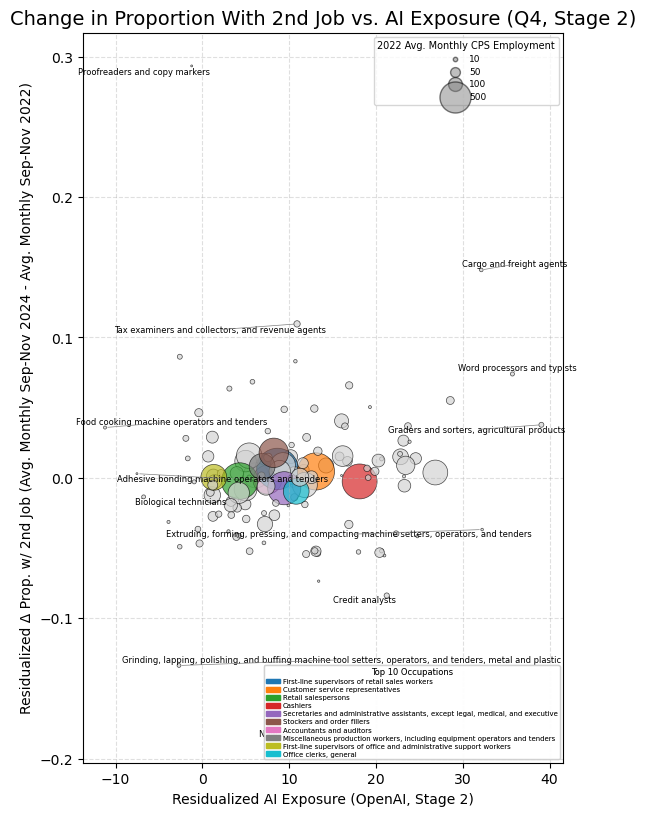

In [106]:
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
import matplotlib.patches as mpatches
import pandas as pd
import textwrap
import statsmodels.api as sm
import numpy as np

# Load data
df = pd.read_stata("Data/Cleaned/6M_residuals_for_plots.dta")

# Clean and prep
plot_df = df[['cps_code', 'cps_title', 'openai2_resid', 'd_other_job_resid', 'avg_monthly_emp','DQ4_openai2']].dropna()
plot_df['cps_code'] = plot_df['cps_code'].astype(str)
plot_df = plot_df[plot_df['DQ4_openai2'] == 1].copy()

# Top 10 occupations
top_cps_codes = ['4700', '5240', '4760', '4720', '5740', '9645', '800', '8990', '5000', '5860']
palette = sns.color_palette("tab10", len(top_cps_codes))
color_map = dict(zip(top_cps_codes, palette))

# Assign colors
plot_df['color'] = plot_df['cps_code'].apply(lambda x: color_map[x] if x in top_cps_codes else 'lightgray')

# Define edge outliers using axis extremes
edge_df = pd.concat([
    plot_df.nsmallest(3, 'openai2_resid'),
    plot_df.nlargest(3, 'openai2_resid'),
    plot_df.nsmallest(3, 'd_other_job_resid'),
    plot_df.nlargest(3, 'd_other_job_resid')
]).drop_duplicates()

# Label only those outliers
plot_df['edge_label'] = plot_df.apply(
    lambda row: row['cps_title'] if row['cps_title'] in edge_df['cps_title'].values else None,
    axis=1
)

# Create plot
fig, ax = plt.subplots(figsize=(8, 10))

# Bubble scatter
ax.scatter(
    plot_df['openai2_resid'],
    plot_df['d_other_job_resid'],
    s=plot_df['avg_monthly_emp'],
    color=plot_df['color'],
    alpha=0.7,
    edgecolors='black',
    linewidths=0.5
)

# --- Bubble Size Legend (top right) ---
bubble_legend = [
    plt.scatter([], [], s=size, c='gray', alpha=0.5, edgecolors='k', label=f'{size:,}')
    for size in [10, 50, 100, 500]
]

bubble_legend_obj = ax.legend(
    handles=bubble_legend,
    title='2022 Avg. Monthly CPS Employment',
    loc='upper right',
    fontsize=6.5,
    title_fontsize=7,
    frameon=True,
    labelspacing=0.4,
    handletextpad=0.5,
    borderpad=0.4
)

# --- Occupation Color Legend (bottom right) ---
patches = [
    mpatches.Patch(color=color_map[code], label=plot_df[plot_df['cps_code'] == code]['cps_title'].iloc[0])
    for code in top_cps_codes
]

occupation_legend_obj = ax.legend(
    handles=patches,
    title='Top 10 Occupations',
    loc='lower right',
    fontsize=5,
    title_fontsize=6,
    frameon=True,
    labelspacing=0.3,
    handletextpad=0.4,
    borderpad=0.3,
    ncol=1
)

# Add both legends to plot
ax.add_artist(bubble_legend_obj)
ax.add_artist(occupation_legend_obj)


from adjustText import adjust_text

texts = []

# Create label texts directly *at the point* — let adjustText do all movement
for _, row in plot_df[plot_df['edge_label'].notnull()].iterrows():
    texts.append(
        ax.text(
            row['openai2_resid'],
            row['d_other_job_resid'],
            row['edge_label'],
            fontsize=6,
            ha='center',
            va='center'
        )
    )

# Adjust placement with proper arrows
adjust_text(
    texts,
    x=plot_df.loc[plot_df['edge_label'].notnull(), 'openai2_resid'],
    y=plot_df.loc[plot_df['edge_label'].notnull(), 'd_other_job_resid'],
    arrowprops=dict(
        arrowstyle='-', 
        color='gray', 
        lw=0.5,
        shrinkA=2,  # shrink arrowhead from text
        shrinkB=2   # shrink arrowhead from point
    ),
    expand_text=(1.2, 1.4),
    expand_points=(1.2, 1.4),
    ax=ax
)


# Final polish
ax.set_title("Change in Proportion With 2nd Job vs. AI Exposure (Q4, Stage 2)", fontsize=14)
ax.set_xlabel("Residualized AI Exposure (OpenAI, Stage 2)")
ax.set_ylabel("Residualized Δ Prop. w/ 2nd Job (Avg. Monthly Sep-Nov 2024 - Avg. Monthly Sep-Nov 2022)")
ax.grid(True, linestyle='--', alpha=0.4)

fig.tight_layout()
fig.subplots_adjust(right=0.75, left=0.15, top=0.88, bottom=0.15)

# Save
plt.savefig("Output/April/Bubble3/Q4_OJ_6MS2_OA.png", dpi=300, bbox_inches='tight')
plt.show()


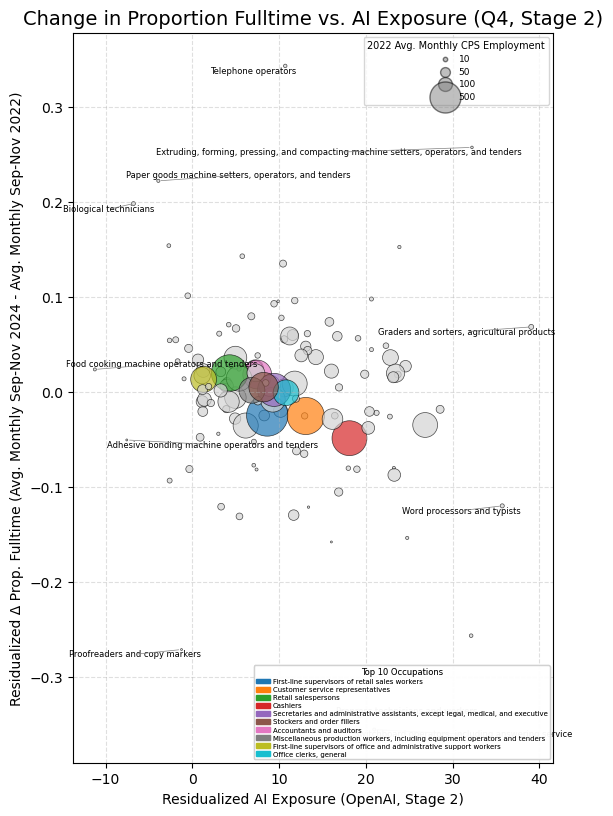

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
import matplotlib.patches as mpatches
import pandas as pd
import textwrap
import statsmodels.api as sm
import numpy as np

# Load data
df = pd.read_stata("Data/Cleaned/6M_residuals_for_plots.dta")

# Clean and prep
plot_df = df[['cps_code', 'cps_title', 'openai2_resid', 'd_fulltime_resid', 'avg_monthly_emp','DQ4_openai2']].dropna()
plot_df['cps_code'] = plot_df['cps_code'].astype(str)
plot_df = plot_df[plot_df['DQ4_openai2'] == 1].copy()

# Top 10 occupations
top_cps_codes = ['4700', '5240', '4760', '4720', '5740', '9645', '800', '8990', '5000', '5860']
palette = sns.color_palette("tab10", len(top_cps_codes))
color_map = dict(zip(top_cps_codes, palette))

# Assign colors
plot_df['color'] = plot_df['cps_code'].apply(lambda x: color_map[x] if x in top_cps_codes else 'lightgray')

# Define edge outliers using axis extremes
edge_df = pd.concat([
    plot_df.nsmallest(3, 'openai2_resid'),
    plot_df.nlargest(3, 'openai2_resid'),
    plot_df.nsmallest(3, 'd_fulltime_resid'),
    plot_df.nlargest(3, 'd_fulltime_resid')
]).drop_duplicates()

# Label only those outliers
plot_df['edge_label'] = plot_df.apply(
    lambda row: row['cps_title'] if row['cps_title'] in edge_df['cps_title'].values else None,
    axis=1
)

# Create plot
fig, ax = plt.subplots(figsize=(8, 10))

# Bubble scatter
ax.scatter(
    plot_df['openai2_resid'],
    plot_df['d_fulltime_resid'],
    s=plot_df['avg_monthly_emp'],
    color=plot_df['color'],
    alpha=0.7,
    edgecolors='black',
    linewidths=0.5
)

# --- Bubble Size Legend (top right) ---
bubble_legend = [
    plt.scatter([], [], s=size, c='gray', alpha=0.5, edgecolors='k', label=f'{size:,}')
    for size in [10, 50, 100, 500]
]

bubble_legend_obj = ax.legend(
    handles=bubble_legend,
    title='2022 Avg. Monthly CPS Employment',
    loc='upper right',
    fontsize=6.5,
    title_fontsize=7,
    frameon=True,
    labelspacing=0.4,
    handletextpad=0.5,
    borderpad=0.4
)

# --- Occupation Color Legend (bottom right) ---
patches = [
    mpatches.Patch(color=color_map[code], label=plot_df[plot_df['cps_code'] == code]['cps_title'].iloc[0])
    for code in top_cps_codes
]

occupation_legend_obj = ax.legend(
    handles=patches,
    title='Top 10 Occupations',
    loc='lower right',
    fontsize=5,
    title_fontsize=6,
    frameon=True,
    labelspacing=0.3,
    handletextpad=0.4,
    borderpad=0.3,
    ncol=1
)

# Add both legends to plot
ax.add_artist(bubble_legend_obj)
ax.add_artist(occupation_legend_obj)


from adjustText import adjust_text

texts = []

# Create label texts directly *at the point* — let adjustText do all movement
for _, row in plot_df[plot_df['edge_label'].notnull()].iterrows():
    texts.append(
        ax.text(
            row['openai2_resid'],
            row['d_fulltime_resid'],
            row['edge_label'],
            fontsize=6,
            ha='center',
            va='center'
        )
    )

# Adjust placement with proper arrows
adjust_text(
    texts,
    x=plot_df.loc[plot_df['edge_label'].notnull(), 'openai2_resid'],
    y=plot_df.loc[plot_df['edge_label'].notnull(), 'd_fulltime_resid'],
    arrowprops=dict(
        arrowstyle='-', 
        color='gray', 
        lw=0.5,
        shrinkA=2,  # shrink arrowhead from text
        shrinkB=2   # shrink arrowhead from point
    ),
    expand_text=(1.2, 1.4),
    expand_points=(1.2, 1.4),
    ax=ax
)


# Final polish
ax.set_title("Change in Proportion Fulltime vs. AI Exposure (Q4, Stage 2)", fontsize=14)
ax.set_xlabel("Residualized AI Exposure (OpenAI, Stage 2)")
ax.set_ylabel("Residualized Δ Prop. Fulltime (Avg. Monthly Sep-Nov 2024 - Avg. Monthly Sep-Nov 2022)")
ax.grid(True, linestyle='--', alpha=0.4)

fig.tight_layout()
fig.subplots_adjust(right=0.75, left=0.15, top=0.88, bottom=0.15)

# Save
plt.savefig("Output/April/Bubble3/Q4_FT_6MS2_OA.png", dpi=300, bbox_inches='tight')
plt.show()


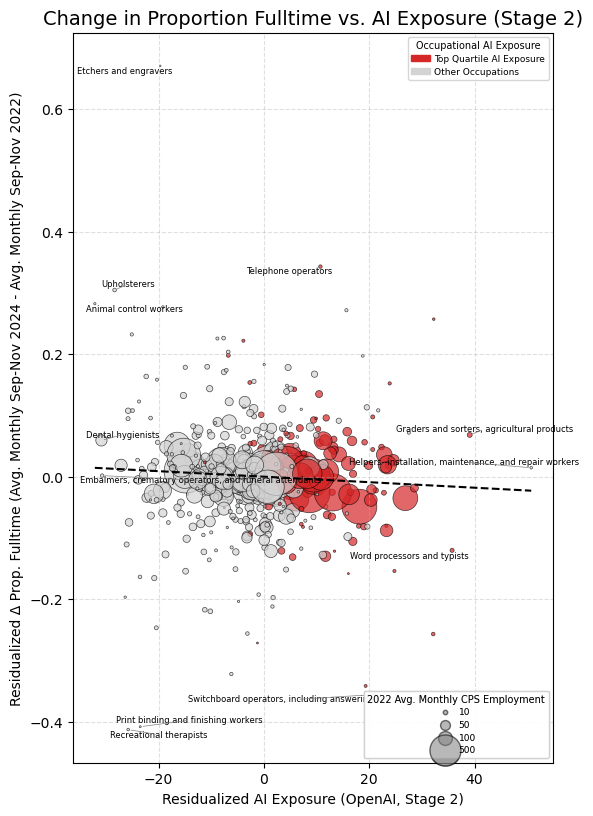

In [110]:
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
import matplotlib.patches as mpatches
import pandas as pd
import textwrap
import statsmodels.api as sm
import numpy as np

# Load data
df = pd.read_stata("Data/Cleaned/6M_residuals_for_plots.dta")

# Clean and prep
plot_df = df[['cps_code', 'cps_title', 'openai2_resid', 'd_fulltime_resid', 'avg_monthly_emp', 'DQ4_openai2']].dropna()
plot_df['cps_code'] = plot_df['cps_code'].astype(str)

# Assign colors based on exposure quartile
plot_df['color'] = plot_df['DQ4_openai2'].apply(lambda x: 'tab:red' if x == 1 else 'lightgray')

# Define edge outliers using axis extremes
edge_df = pd.concat([
    plot_df.nsmallest(3, 'openai2_resid'),
    plot_df.nlargest(3, 'openai2_resid'),
    plot_df.nsmallest(3, 'd_fulltime_resid'),
    plot_df.nlargest(3, 'd_fulltime_resid')
]).drop_duplicates()

# Label only those outliers
plot_df['edge_label'] = plot_df.apply(
    lambda row: row['cps_title'] if row['cps_title'] in edge_df['cps_title'].values else None,
    axis=1
)

# Create plot
fig, ax = plt.subplots(figsize=(8, 10))

# Bubble scatter
ax.scatter(
    plot_df['openai2_resid'],
    plot_df['d_fulltime_resid'],
    s=plot_df['avg_monthly_emp'],
    color=plot_df['color'],
    alpha=0.7,
    edgecolors='black',
    linewidths=0.5
)

# Drop NA rows used for regression
dfw = plot_df.dropna(subset=['openai2_resid', 'd_fulltime_resid', 'avg_monthly_emp'])

# Define X, y, and weights
X = sm.add_constant(dfw['openai2_resid'])
y = dfw['d_fulltime_resid']
weights = dfw['avg_monthly_emp']

# Fit weighted least squares model
wls_model = sm.WLS(y, X, weights=weights)
results = wls_model.fit()

# Predict values for plotting the regression line
x_vals = np.linspace(dfw['openai2_resid'].min(), dfw['openai2_resid'].max(), 100)
X_pred = sm.add_constant(x_vals)
y_pred = results.predict(X_pred)

# Plot weighted regression line
ax.plot(x_vals, y_pred, color='black', linestyle='--', linewidth=1.5, label='Weighted Regression')
ax.legend()

# --- Legend: Exposure quartile (bottom right) ---
exposure_patches = [
    mpatches.Patch(color='tab:red', label='Top Quartile AI Exposure'),
    mpatches.Patch(color='lightgray', label='Other Occupations')
]

exposure_legend = ax.legend(
    handles=exposure_patches,
    title='Occupational AI Exposure',
    loc='upper right',
    fontsize=6.5,
    title_fontsize=7,
    frameon=True,
    labelspacing=0.4,
    handletextpad=0.5,
    borderpad=0.4,
    ncol=1
)

# --- Legend: Bubble size (top right) ---
bubble_legend = [
    plt.scatter([], [], s=size, c='gray', alpha=0.5, edgecolors='k', label=f'{size:,}')
    for size in [10, 50, 100, 500]
]

bubble_legend = ax.legend(
    handles=bubble_legend,
    title='2022 Avg. Monthly CPS Employment',
    loc='lower right',
    fontsize=6.5,
    title_fontsize=7,
    frameon=True,
    labelspacing=0.4,
    handletextpad=0.5,
    borderpad=0.4
)

# Add both legends to the plot
ax.add_artist(exposure_legend)
ax.add_artist(bubble_legend)



# Label extreme points
texts = []
for _, row in plot_df[plot_df['edge_label'].notnull()].iterrows():
    texts.append(
        ax.text(
            row['openai2_resid'],
            row['d_fulltime_resid'],
            row['edge_label'],
            fontsize=6,
            ha='center',
            va='center'
        )
    )

adjust_text(
    texts,
    x=plot_df.loc[plot_df['edge_label'].notnull(), 'openai2_resid'],
    y=plot_df.loc[plot_df['edge_label'].notnull(), 'd_fulltime_resid'],
    arrowprops=dict(
        arrowstyle='-', 
        color='gray', 
        lw=0.5,
        shrinkA=2,
        shrinkB=2
    ),
    expand_text=(1.2, 1.4),
    expand_points=(1.2, 1.4),
    ax=ax
)

# Final polish
ax.set_title("Change in Proportion Fulltime vs. AI Exposure (Stage 2)", fontsize=14)
ax.set_xlabel("Residualized AI Exposure (OpenAI, Stage 2)")
ax.set_ylabel("Residualized Δ Prop. Fulltime (Avg. Monthly Sep-Nov 2024 - Avg. Monthly Sep-Nov 2022)")
ax.grid(True, linestyle='--', alpha=0.4)

fig.tight_layout()
fig.subplots_adjust(right=0.75, left=0.15, top=0.88, bottom=0.15)

# Save
plt.savefig("Output/April/Bubble3/QC_FT_6MS2_OA.png", dpi=300, bbox_inches='tight')
plt.show()
